# GraphSAGE Extrapolation Testing

This notebook evaluates trained models from the extrapolation experiments on unseen distances (d=9, d=11).

**Workflow:**
1. Load trained models from different split experiments
2. Generate/load test datasets for d=9 and d=11
3. Evaluate accuracy across different physical error rates
4. Compare extrapolation performance across split configurations

**Key Questions:**
- Can models trained on d=3,5,7 generalize to d=9,11?
- Does the training data split (d=3/d=5/d=7 ratio) affect extrapolation?
- Which split configuration extrapolates best?

## Imports

In [1]:
import sys
import json
import random
import time
from pathlib import Path
from datetime import datetime

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
else:
    BASE_PATH = Path('../..')  # code/gSAGE/extrapolation -> code/

sys.path.insert(0, str(BASE_PATH))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from torch_geometric.loader import DataLoader
from scipy import stats
from scipy.optimize import curve_fit

# Import from models.py
from models import (
    SurfaceCodeSampler,
    SparseGraph,
    GraphSAGEModel,
    GraphSAGE,
    DatasetCache,
    ler_mwpm,
)

# Set up paths
EXTRAPOLATION_DIR = BASE_PATH / "gSAGE" / "extrapolation"
RESULTS_DIR = EXTRAPOLATION_DIR / "results" / "revised_training"
MODELS_DIR = EXTRAPOLATION_DIR / "models" / "revised_training"
PLOTS_DIR = EXTRAPOLATION_DIR / "plots" / "revised_training"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\nPaths:")
print(f"  BASE_PATH: {BASE_PATH}")
print(f"  MODELS_DIR: {MODELS_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
print(f"  PLOTS_DIR: {PLOTS_DIR}")

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti

Paths:
  BASE_PATH: ..\..
  MODELS_DIR: ..\..\gSAGE\extrapolation\models\revised_training
  RESULTS_DIR: ..\..\gSAGE\extrapolation\results\revised_training
  PLOTS_DIR: ..\..\gSAGE\extrapolation\plots\revised_training


## Configuration

In [2]:
# =============================================================================
# TESTING CONFIGURATION
# =============================================================================

# Distances to test extrapolation on
TEST_DISTANCES = [9, 11, 13]

# Physical error rates for testing
P_VALUES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

# Number of samples per distance per error rate
SAMPLES_PER_P = 10000

# Batch size for inference
BATCH_SIZE = 256

# K-neighbors for SparseGraph (should match training)
K_NEIGHBORS = 6

# Random seed
SEED = 42

print(f"Testing Configuration:")
print(f"  Test distances: {TEST_DISTANCES}")
print(f"  P values: {P_VALUES}")
print(f"  Samples per (distance, p): {SAMPLES_PER_P:,}")
print(f"  Total test samples per distance: {SAMPLES_PER_P * len(P_VALUES):,}")

Testing Configuration:
  Test distances: [9, 11, 13]
  P values: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
  Samples per (distance, p): 10,000
  Total test samples per distance: 80,000


In [3]:
# =============================================================================
# SPLIT EXPERIMENTS (must match training.ipynb)
# =============================================================================

SPLIT_EXPERIMENTS = {
    # Control
    'equal_333333': {'d3': 0.33, 'd5': 0.33, 'd7': 0.34, 'hypothesis': 'Reference baseline'},
    
    # Experiment A: Vary d=3 amount (d5:d7 = 1:1)
    'a1_d3_00': {'d3': 0.00, 'd5': 0.50, 'd7': 0.50, 'hypothesis': 'No d=3 data'},
    'a2_d3_10': {'d3': 0.10, 'd5': 0.45, 'd7': 0.45, 'hypothesis': '10% d=3 data'},
    'a3_d3_20': {'d3': 0.20, 'd5': 0.40, 'd7': 0.40, 'hypothesis': '20% d=3 data'},
    'a4_d3_40': {'d3': 0.40, 'd5': 0.30, 'd7': 0.30, 'hypothesis': '40% d=3 data'},
    'a5_d3_50': {'d3': 0.50, 'd5': 0.25, 'd7': 0.25, 'hypothesis': '50% d=3 data (heavy)'},
    
    # Experiment B: Vary d5:d7 ratio (no d=3)
    'b1_d5heavy': {'d3': 0.00, 'd5': 0.80, 'd7': 0.20, 'hypothesis': 'd5-heavy (80/20)'},
    'b2_d5more':  {'d3': 0.00, 'd5': 0.65, 'd7': 0.35, 'hypothesis': 'd5-more (65/35)'},
    'b3_balanced': {'d3': 0.00, 'd5': 0.50, 'd7': 0.50, 'hypothesis': 'Balanced (50/50)'},
    'b4_d7more':  {'d3': 0.00, 'd5': 0.35, 'd7': 0.65, 'hypothesis': 'd7-more (35/65)'},
    'b5_d7heavy': {'d3': 0.00, 'd5': 0.20, 'd7': 0.80, 'hypothesis': 'd7-heavy (20/80)'},
    
    # Experiment C: Extreme/boundary cases
    'c1_only_d3': {'d3': 1.00, 'd5': 0.00, 'd7': 0.00, 'hypothesis': 'Only d=3 training'},
    'c2_only_d5': {'d3': 0.00, 'd5': 1.00, 'd7': 0.00, 'hypothesis': 'Only d=5 training'},
    'c3_only_d7': {'d3': 0.00, 'd5': 0.00, 'd7': 1.00, 'hypothesis': 'Only d=7 training'},
    'c4_no_d7':   {'d3': 0.50, 'd5': 0.50, 'd7': 0.00, 'hypothesis': 'No d=7 data'},
}

print("Split Experiments:")
for name in SPLIT_EXPERIMENTS:
    print(f"  - {name}")

Split Experiments:
  - equal_333333
  - a1_d3_00
  - a2_d3_10
  - a3_d3_20
  - a4_d3_40
  - a5_d3_50
  - b1_d5heavy
  - b2_d5more
  - b3_balanced
  - b4_d7more
  - b5_d7heavy
  - c1_only_d3
  - c2_only_d5
  - c3_only_d7
  - c4_no_d7


## Helper Functions

In [4]:
def list_available_models(include_checkpoints: bool = False):
    """List trained extrapolation models in `MODELS_DIR`.

    By default this **excludes** checkpoint files ("*_checkpoint.pt") since those
    are not full saved models and won't have the same metadata.

    Returns:
        List[str]: model names (without .pt extension)
    """
    models = []
    if MODELS_DIR.exists():
        for model_file in MODELS_DIR.glob("*.pt"):
            stem = model_file.stem
            is_checkpoint = stem.endswith("_checkpoint") or ("checkpoint" in stem)
            if (not include_checkpoints) and is_checkpoint:
                continue
            models.append(stem)
    return sorted(models)

print("Available trained models (excluding checkpoints):")
available_models = list_available_models(include_checkpoints=False)
if available_models:
    for m in available_models:
        print(f"  - {m}")
else:
    print("  No models found. Run training.ipynb first.")

Available trained models (excluding checkpoints):
  - a1_d3_00
  - a2_d3_10
  - a3_d3_20
  - a4_d3_40
  - a5_d3_50
  - b1_d5heavy
  - b2_d5more
  - b3_balanced
  - b4_d7more
  - b5_d7heavy
  - c4_no_d7
  - equal_333333


In [5]:
def load_trained_model(split_name: str):
    """Load a trained extrapolation GraphSAGE model.

    Notes:
    - This function **will not load** checkpoint files ("*_checkpoint.pt").
    - Expected save format is the one used in `training.ipynb`:
      `{'state_dict': ..., 'config': ..., 'split_config': ..., ...}`
    """

    if split_name.endswith("_checkpoint") or ("checkpoint" in split_name):
        raise ValueError(f"Refusing to load checkpoint model: {split_name}")

    model_path = MODELS_DIR / f"{split_name}.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    save_obj = torch.load(model_path, map_location=device, weights_only=False)

    # ------------------------------
    # Extract state_dict + config
    # ------------------------------
    config = None
    state_dict = None
    metadata = {
        'split_name': split_name,
        'split_config': {},
        'hyperparams': {},
        'metrics': {},
        'timestamp': '',
    }

    def _infer_config_from_results_json():
        """Fallback: infer model config from the saved training JSON (if present)."""
        results_path = RESULTS_DIR / f"{split_name}_training.json"
        if not results_path.exists():
            return None
        with open(results_path, 'r') as f:
            results = json.load(f)
        hp = results.get('hyperparams', {})
        # GraphSAGE in this repo defaults to in_channels=5 for SparseGraph.
        return {
            'in_channels': hp.get('in_channels', 5),
            'hidden_dim': hp.get('hidden_dim', 128),
            'num_layers': hp.get('num_layers', 4),
            'dropout': hp.get('dropout', 0.0),
            'aggr': hp.get('aggr', 'mean'),
        }

    if isinstance(save_obj, dict) and ('state_dict' in save_obj) and ('config' in save_obj):
        state_dict = save_obj['state_dict']
        config = save_obj['config']
        metadata.update({
            'split_name': save_obj.get('split_name', split_name),
            'split_config': save_obj.get('split_config', {}),
            'hyperparams': save_obj.get('hyperparams', {}),
            'metrics': save_obj.get('metrics', {}),
            'timestamp': save_obj.get('timestamp', ''),
        })
    elif isinstance(save_obj, dict) and ('state_dict' in save_obj) and ('config' not in save_obj):
        state_dict = save_obj['state_dict']
        config = _infer_config_from_results_json()
    elif isinstance(save_obj, dict) and ('model_state_dict' in save_obj):
        # Common checkpoint format
        state_dict = save_obj['model_state_dict']
        config = _infer_config_from_results_json()
    elif isinstance(save_obj, dict):
        # Might be a bare state_dict
        state_dict = save_obj
        config = _infer_config_from_results_json()

    if config is None or state_dict is None:
        if isinstance(save_obj, dict):
            keys = sorted(save_obj.keys())
            raise KeyError(
                f"Could not extract (config, state_dict) from {model_path}. "
                f"Top-level keys: {keys}. "
                f"This often happens if you accidentally saved a checkpoint or only a state_dict."
            )
        raise TypeError(f"Unexpected object type in {model_path}: {type(save_obj)}")

    # ------------------------------
    # Instantiate model
    # ------------------------------
    model = GraphSAGE(
        nickname=f"extrapolation_{split_name}",
        in_channels=config.get('in_channels', 5),
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config.get('dropout', 0.0),
        aggr=config.get('aggr', 'mean'),
        device=device,
        base_path=BASE_PATH,
    )

    model.model.load_state_dict(state_dict)
    model.model.eval()

    print(f"Loaded model: {split_name}")
    print(f"  Config: {config}")
    if metadata.get('metrics'):
        print(f"  Training val_acc: {metadata['metrics'].get('val_accuracy', 0)*100:.2f}%")

    return model, metadata

In [6]:
def generate_test_dataset(d: int, p: float, n_samples: int):
    """
    Generate test dataset for a specific distance and error rate.
    
    Args:
        d: Code distance
        p: Physical error rate
        n_samples: Number of samples
        
    Returns:
        List of PyG Data objects
    """
    sampler = SurfaceCodeSampler(p=p, device=device)
    graph_builder = SparseGraph(k_neighbors=K_NEIGHBORS, device=device)
    
    # Generate samples
    detections, labels = sampler.sample(
        d=d,
        num_samples=n_samples,
        p_values=[p],
        p_weights=[1.0]
    )
    
    # Convert to graphs
    graphs = []
    for i in range(n_samples):
        graph = graph_builder.to_pyg(detections[i], labels[i])
        graphs.append(graph)
    
    return graphs

In [7]:
def load_or_generate_test_data(d: int, n_samples_per_p: int, p_values: list, use_cache: bool = True):
    """
    Load test data from cache or generate it.
    
    Args:
        d: Code distance
        n_samples_per_p: Samples per error rate
        p_values: List of error rates
        use_cache: Whether to try loading from cache
        
    Returns:
        Dict mapping p -> list of graphs
    """
    cache_name = f"d{d}_extrapolation_test"
    
    # Try to load from cache
    if use_cache:
        cache = DatasetCache(base_path=BASE_PATH, device=device)
        try:
            cache.load(cache_name, verbose=True)
            total_needed = n_samples_per_p * len(p_values)
            if cache.size() >= total_needed:
                print(f"Using cached dataset: {cache_name}")
                all_graphs = cache.get_graphs(shuffle=False)
                # Split by p_value (assuming equal distribution in cache)
                graphs_per_p = len(all_graphs) // len(p_values)
                return {p: all_graphs[i*graphs_per_p:(i+1)*graphs_per_p] 
                        for i, p in enumerate(p_values)}
        except FileNotFoundError:
            print(f"Cache not found: {cache_name}. Generating...")
    
    # Generate data for each p value
    test_data = {}
    print(f"\nGenerating test data for d={d}...")
    
    for p in tqdm(p_values, desc=f"d={d}"):
        graphs = generate_test_dataset(d, p, n_samples_per_p)
        test_data[p] = graphs
    
    return test_data

In [8]:
def evaluate_model_on_data(model, graphs, batch_size=256):
    """
    Evaluate model accuracy on test data.
    
    Args:
        model: GraphSAGE model wrapper
        graphs: List of PyG Data objects
        batch_size: Batch size for inference
        
    Returns:
        Accuracy as float
    """
    model.model.eval()
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model.model(batch)
            y = batch.y.float().view(-1, 1)
            correct += ((pred > 0.5).float() == y).sum().item()
            total += y.size(0)
    
    return correct / total if total > 0 else 0.0

In [9]:
# =============================================================================
# QEC-STANDARD ANALYSIS FUNCTIONS
# =============================================================================

def compute_error_suppression_factor(ler_dict: dict, d1: int, d2: int) -> float:
    """
    Compute error suppression factor Λ = LER(d1) / LER(d2).
    
    Uses average LER across all error rates for each distance.
    
    Args:
        ler_dict: Dict mapping (split_name, distance, p_value) -> LER
        d1: First distance (smaller)
        d2: Second distance (larger, should be d1+2)
        
    Returns:
        Error suppression factor Λ
    """
    # Get all LER values for each distance
    ler_d1 = [ler for (split, d, p), ler in ler_dict.items() if d == d1]
    ler_d2 = [ler for (split, d, p), ler in ler_dict.items() if d == d2]
    
    if len(ler_d1) == 0 or len(ler_d2) == 0:
        return np.nan
    
    avg_ler_d1 = np.mean(ler_d1)
    avg_ler_d2 = np.mean(ler_d2)
    
    if avg_ler_d2 == 0:
        return np.inf
    
    return avg_ler_d1 / avg_ler_d2


def fit_scaling_exponent(p_values: np.ndarray, ler_values: np.ndarray) -> tuple:
    """
    Fit power-law scaling: LER = C * p^α
    
    Fits log(LER) = log(C) + α * log(p)
    
    Args:
        p_values: Physical error rates
        ler_values: Logical error rates
        
    Returns:
        Tuple of (exponent α, intercept log(C), R²)
    """
    # Filter out zero/negative values for log
    mask = (p_values > 0) & (ler_values > 0)
    if mask.sum() < 3:  # Need at least 3 points
        return np.nan, np.nan, np.nan
    
    log_p = np.log(p_values[mask])
    log_ler = np.log(ler_values[mask])
    
    # Linear fit: log(LER) = a + b * log(p)
    coeffs = np.polyfit(log_p, log_ler, 1)
    alpha = coeffs[0]  # Exponent
    log_C = coeffs[1]  # Intercept
    
    # Compute R²
    log_ler_pred = np.polyval(coeffs, log_p)
    ss_res = np.sum((log_ler - log_ler_pred) ** 2)
    ss_tot = np.sum((log_ler - np.mean(log_ler)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return alpha, log_C, r_squared


def bootstrap_standard_error(data: np.ndarray, n_bootstrap: int = 1000, confidence: float = 0.95) -> tuple:
    """
    Compute bootstrap standard error and confidence interval.
    
    Args:
        data: Array of values to bootstrap
        n_bootstrap: Number of bootstrap samples
        confidence: Confidence level (default 0.95 for 95% CI)
        
    Returns:
        Tuple of (standard_error, lower_ci, upper_ci)
    """
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    
    n = len(data)
    bootstrap_means = []
    
    np.random.seed(SEED)  # For reproducibility
    for _ in range(n_bootstrap):
        # Resample with replacement
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_means.append(np.mean(sample))
    
    bootstrap_means = np.array(bootstrap_means)
    se = np.std(bootstrap_means)
    
    # Confidence interval
    alpha = 1 - confidence
    lower_ci = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper_ci = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    
    return se, lower_ci, upper_ci


def compute_ler_ratio(model_ler: float, mwpm_ler: float) -> float:
    """
    Compute LER ratio: model_ler / mwpm_ler
    
    Values < 1 mean model outperforms MWPM.
    
    Args:
        model_ler: Model's logical error rate
        mwpm_ler: MWPM's logical error rate
        
    Returns:
        LER ratio
    """
    if mwpm_ler == 0:
        return np.inf if model_ler > 0 else np.nan
    return model_ler / mwpm_ler


def estimate_threshold(p_values: np.ndarray, ler_curves: dict) -> dict:
    """
    Estimate threshold where LER curves cross.
    
    Threshold is where LER(d) ≈ LER(d+2) for different distances.
    
    Args:
        p_values: Physical error rates
        ler_curves: Dict mapping distance -> array of LER values
        
    Returns:
        Dict with threshold estimates for each distance pair
    """
    thresholds = {}
    distances = sorted(ler_curves.keys())
    
    for i in range(len(distances) - 1):
        d1, d2 = distances[i], distances[i+1]
        ler1 = np.array(ler_curves[d1])
        ler2 = np.array(ler_curves[d2])
        
        # Find where curves cross (LER1 ≈ LER2)
        diff = np.abs(ler1 - ler2)
        min_idx = np.argmin(diff)
        
        if min_idx < len(p_values):
            thresholds[f"d{d1}_d{d2}"] = {
                'p_threshold': p_values[min_idx],
                'ler_at_threshold': (ler1[min_idx] + ler2[min_idx]) / 2,
                'difference': diff[min_idx]
            }
    
    return thresholds


def wilcoxon_test_split_comparison(df_results: pd.DataFrame, split1: str, split2: str) -> dict:
    """
    Perform Wilcoxon signed-rank test comparing two splits.
    
    Args:
        df_results: DataFrame with results
        split1: First split name
        split2: Second split name
        
    Returns:
        Dict with test statistics and p-value
    """
    # Get matching (distance, p_value) pairs
    subset1 = df_results[df_results['split_name'] == split1].set_index(['distance', 'p_value'])['accuracy']
    subset2 = df_results[df_results['split_name'] == split2].set_index(['distance', 'p_value'])['accuracy']
    
    # Align indices
    common_idx = subset1.index.intersection(subset2.index)
    if len(common_idx) == 0:
        return {'statistic': np.nan, 'pvalue': np.nan, 'significant': False}
    
    acc1 = subset1.loc[common_idx].values
    acc2 = subset2.loc[common_idx].values
    
    # Perform Wilcoxon test
    try:
        statistic, pvalue = stats.wilcoxon(acc1, acc2, alternative='two-sided')
        significant = pvalue < 0.05
    except ValueError:
        statistic, pvalue = np.nan, np.nan
        significant = False
    
    return {
        'statistic': statistic,
        'pvalue': pvalue,
        'significant': significant,
        'mean_diff': np.mean(acc1 - acc2),
        'n_samples': len(common_idx)
    }

print("QEC-standard analysis functions loaded")

QEC-standard analysis functions loaded


In [10]:
def compute_mwpm_baseline(d: int, p_values: list, n_shots: int = 10000):
    """
    Compute MWPM decoder logical error rate for comparison.
    
    Args:
        d: Code distance
        p_values: List of error rates
        n_shots: Number of shots per error rate
        
    Returns:
        Dict mapping p -> logical error rate
    """
    mwpm_ler = {}
    print(f"\nComputing MWPM baseline for d={d}...")
    
    for p in tqdm(p_values, desc=f"MWPM d={d}"):
        ler = ler_mwpm(p, d, num_shots=n_shots)
        mwpm_ler[p] = ler
    
    return mwpm_ler

## Load Models and Test Data

In [11]:
# Select which models to evaluate
# Set to None to evaluate all available models, or specify a list
MODELS_TO_EVALUATE = None  # e.g., ['equal_333333', 'a1_d3_00', 'b5_d7heavy']

if MODELS_TO_EVALUATE is None:
    models_to_evaluate = list_available_models()
else:
    models_to_evaluate = MODELS_TO_EVALUATE

if not models_to_evaluate:
    print("WARNING: No models to evaluate. Run training.ipynb first.")
else:
    print(f"Models to evaluate: {models_to_evaluate}")

Models to evaluate: ['a1_d3_00', 'a2_d3_10', 'a3_d3_20', 'a4_d3_40', 'a5_d3_50', 'b1_d5heavy', 'b2_d5more', 'b3_balanced', 'b4_d7more', 'b5_d7heavy', 'c4_no_d7', 'equal_333333']


In [12]:
# Load all models
loaded_models = {}

for split_name in models_to_evaluate:
    try:
        model, metadata = load_trained_model(split_name)
        loaded_models[split_name] = {'model': model, 'metadata': metadata}
    except (FileNotFoundError, ValueError, KeyError) as e:
        print(f"Skipping {split_name}: {e}")

print(f"\nLoaded {len(loaded_models)} models")

GraphSAGE initialized: GraphSAGE(nickname='extrapolation_a1_d3_00', in_channels=5, hidden_dim=256, num_layers=5, dropout=0.1, aggr='max')
Loaded model: a1_d3_00
  Config: {'in_channels': 5, 'hidden_dim': 256, 'num_layers': 5, 'dropout': 0.1, 'aggr': 'max', 'seed': 42}
  Training val_acc: 96.28%
GraphSAGE initialized: GraphSAGE(nickname='extrapolation_a2_d3_10', in_channels=5, hidden_dim=256, num_layers=5, dropout=0.1, aggr='max')
Loaded model: a2_d3_10
  Config: {'in_channels': 5, 'hidden_dim': 256, 'num_layers': 5, 'dropout': 0.1, 'aggr': 'max', 'seed': 42}
  Training val_acc: 96.48%
GraphSAGE initialized: GraphSAGE(nickname='extrapolation_a3_d3_20', in_channels=5, hidden_dim=256, num_layers=5, dropout=0.1, aggr='max')
Loaded model: a3_d3_20
  Config: {'in_channels': 5, 'hidden_dim': 256, 'num_layers': 5, 'dropout': 0.1, 'aggr': 'max', 'seed': 42}
  Training val_acc: 96.57%
GraphSAGE initialized: GraphSAGE(nickname='extrapolation_a4_d3_40', in_channels=5, hidden_dim=256, num_layers=5,

In [13]:
# Generate or load test data for extrapolation distances
test_data = {}

for d in TEST_DISTANCES:
    print(f"\n{'='*50}")
    print(f"Loading/generating test data for d={d}")
    print(f"{'='*50}")
    test_data[d] = load_or_generate_test_data(d, SAMPLES_PER_P, P_VALUES, use_cache=True)

print(f"\nTest data loaded for distances: {list(test_data.keys())}")


Loading/generating test data for d=9
Cache not found: d9_extrapolation_test. Generating...

Generating test data for d=9...


d=9:   0%|          | 0/8 [00:00<?, ?it/s]

SurfaceCodeSampler initialized:
  Default error rate: 0.001
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


d=9:  12%|█▎        | 1/8 [00:02<00:18,  2.60s/it]

SurfaceCodeSampler initialized:
  Default error rate: 0.002
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


...

SurfaceCodeSampler initialized:
  Default error rate: 0.007
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


d=13:  88%|████████▊ | 7/8 [00:54<00:09,  9.39s/it]

SurfaceCodeSampler initialized:
  Default error rate: 0.008
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


d=13: 100%|██████████| 8/8 [01:06<00:00,  8.29s/it]


Test data loaded for distances: [9, 11, 13]


## Evaluate Extrapolation

In [14]:
# Evaluate all models on all test data
results = []

print(f"\n{'='*70}")
print("EVALUATING EXTRAPOLATION PERFORMANCE")
print(f"{'='*70}")

for split_name, model_info in loaded_models.items():
    model = model_info['model']
    print(f"\nEvaluating: {split_name}")
    
    for d in TEST_DISTANCES:
        print(f"  Distance d={d}:")
        for p in tqdm(P_VALUES, desc=f"    p values", leave=False):
            graphs = test_data[d][p]
            accuracy = evaluate_model_on_data(model, graphs, BATCH_SIZE)
            
            results.append({
                'split_name': split_name,
                'distance': d,
                'p_value': p,
                'accuracy': accuracy,
                'error_rate': 1 - accuracy,  # Model's logical error rate
            })
        
        # Print summary for this distance
        d_results = [r for r in results if r['split_name'] == split_name and r['distance'] == d]
        avg_acc = np.mean([r['accuracy'] for r in d_results])
        print(f"    Average accuracy: {avg_acc*100:.2f}%")

print(f"\n{'='*70}")
print("EVALUATION COMPLETE")
print(f"{'='*70}")


EVALUATING EXTRAPOLATION PERFORMANCE

Evaluating: a1_d3_00
  Distance d=9:


    Average accuracy: 78.82%
  Distance d=11:


    Average accuracy: 66.53%
  Distance d=13:


    Average accuracy: 57.88%

Evaluating: a2_d3_10
  Distance d=9:


    Average accuracy: 79.03%
  Distance d=11:


...

    Average accuracy: 58.95%
  Distance d=13:


    Average accuracy: 55.37%

Evaluating: equal_333333
  Distance d=9:


    Average accuracy: 78.49%
  Distance d=11:


    Average accuracy: 66.40%
  Distance d=13:


    Average accuracy: 58.12%

EVALUATION COMPLETE


In [15]:
# Compute MWPM baseline (optional but useful for comparison)
COMPUTE_MWPM = True  # Set to False to skip MWPM computation

mwpm_results = {}
if COMPUTE_MWPM:
    for d in TEST_DISTANCES:
        mwpm_results[d] = compute_mwpm_baseline(d, P_VALUES, n_shots=SAMPLES_PER_P)
    print("\nMWPM baseline computed")


Computing MWPM baseline for d=9...


MWPM d=9: 100%|██████████| 8/8 [00:01<00:00,  4.83it/s]



Computing MWPM baseline for d=11...


MWPM d=11: 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]



Computing MWPM baseline for d=13...


MWPM d=13: 100%|██████████| 8/8 [00:05<00:00,  1.44it/s]


MWPM baseline computed


## Results Analysis

In [16]:
# Convert to DataFrame for analysis
df_results = pd.DataFrame(results)
print("Results DataFrame:")
print(df_results.head(20))

Results DataFrame:
   split_name  distance  p_value  accuracy  error_rate
0    a1_d3_00         9    0.001    0.9932      0.0068
1    a1_d3_00         9    0.002    0.9609      0.0391
2    a1_d3_00         9    0.003    0.8973      0.1027
3    a1_d3_00         9    0.004    0.8203      0.1797
4    a1_d3_00         9    0.005    0.7423      0.2577
5    a1_d3_00         9    0.006    0.6777      0.3223
6    a1_d3_00         9    0.007    0.6288      0.3712
7    a1_d3_00         9    0.008    0.5850      0.4150
8    a1_d3_00        11    0.001    0.9611      0.0389
9    a1_d3_00        11    0.002    0.8287      0.1713
10   a1_d3_00        11    0.003    0.7176      0.2824
11   a1_d3_00        11    0.004    0.6348      0.3652
12   a1_d3_00        11    0.005    0.5824      0.4176
13   a1_d3_00        11    0.006    0.5470      0.4530
14   a1_d3_00        11    0.007    0.5300      0.4700
15   a1_d3_00        11    0.008    0.5208      0.4792
16   a1_d3_00        13    0.001    0.8752    

## Enhanced QEC-Standard Analysis

In [17]:
# =============================================================================
# ENHANCED DATA PROCESSING: QEC-STANDARD METRICS
# =============================================================================

print("Computing QEC-standard metrics...")

# Ensure LER is computed (already done, but ensure consistency)
df_results['ler'] = df_results['error_rate']  # Already computed as 1 - accuracy

# Add MWPM LER to dataframe for comparison
mwpm_ler_list = []
for _, row in df_results.iterrows():
    d = row['distance']
    p = row['p_value']
    if d in mwpm_results and p in mwpm_results[d]:
        mwpm_ler_list.append(mwpm_results[d][p])
    else:
        mwpm_ler_list.append(np.nan)

df_results['mwpm_ler'] = mwpm_ler_list

# Compute LER ratios (model/MWPM)
df_results['ler_ratio'] = df_results.apply(
    lambda row: compute_ler_ratio(row['ler'], row['mwpm_ler']) if not np.isnan(row['mwpm_ler']) else np.nan,
    axis=1
)

# Compute error suppression factors for each split
suppression_factors = []
for split_name in df_results['split_name'].unique():
    for d_pair in [(9, 11), (11, 13)]:
        d1, d2 = d_pair
        subset1 = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d1)]
        subset2 = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d2)]
        
        if len(subset1) > 0 and len(subset2) > 0:
            avg_ler_d1 = subset1['ler'].mean()
            avg_ler_d2 = subset2['ler'].mean()
            
            if avg_ler_d2 > 0:
                lambda_val = avg_ler_d1 / avg_ler_d2
                suppression_factors.append({
                    'split_name': split_name,
                    'd1': d1,
                    'd2': d2,
                    'lambda': lambda_val,
                    'ler_d1': avg_ler_d1,
                    'ler_d2': avg_ler_d2
                })

df_suppression = pd.DataFrame(suppression_factors)

# Fit scaling exponents for each (split, distance) combination
scaling_results = []
p_array = np.array(P_VALUES)

for split_name in df_results['split_name'].unique():
    for d in TEST_DISTANCES:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        subset = subset.sort_values('p_value')
        
        if len(subset) >= 3:
            ler_array = subset['ler'].values
            alpha, log_C, r_squared = fit_scaling_exponent(p_array, ler_array)
            
            # Theoretical exponent: (d+1)/2
            theoretical_alpha = (d + 1) / 2
            
            scaling_results.append({
                'split_name': split_name,
                'distance': d,
                'fitted_alpha': alpha,
                'theoretical_alpha': theoretical_alpha,
                'alpha_diff': alpha - theoretical_alpha if not np.isnan(alpha) else np.nan,
                'r_squared': r_squared,
                'log_C': log_C
            })

df_scaling = pd.DataFrame(scaling_results)

# Compute bootstrap standard errors for key metrics
bootstrap_stats = []
for split_name in df_results['split_name'].unique():
    for d in TEST_DISTANCES:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        
        if len(subset) > 0:
            # Bootstrap on accuracy
            acc_se, acc_lower, acc_upper = bootstrap_standard_error(subset['accuracy'].values)
            ler_se, ler_lower, ler_upper = bootstrap_standard_error(subset['ler'].values)
            
            bootstrap_stats.append({
                'split_name': split_name,
                'distance': d,
                'accuracy_mean': subset['accuracy'].mean(),
                'accuracy_se': acc_se,
                'accuracy_ci_lower': acc_lower,
                'accuracy_ci_upper': acc_upper,
                'ler_mean': subset['ler'].mean(),
                'ler_se': ler_se,
                'ler_ci_lower': ler_lower,
                'ler_ci_upper': ler_upper
            })

df_bootstrap = pd.DataFrame(bootstrap_stats)

print(f"✓ Computed error suppression factors for {len(df_suppression)} configurations")
print(f"✓ Fitted scaling exponents for {len(df_scaling)} configurations")
print(f"✓ Computed bootstrap statistics for {len(df_bootstrap)} configurations")

Computing QEC-standard metrics...
✓ Computed error suppression factors for 24 configurations
✓ Fitted scaling exponents for 36 configurations
✓ Computed bootstrap statistics for 36 configurations


### Statistical Significance Tests

In [18]:
# =============================================================================
# STATISTICAL SIGNIFICANCE TESTS
# =============================================================================

print("Performing statistical significance tests...")

# Compare key splits using Wilcoxon test
key_comparisons = [
    # Experiment A: Effect of d=3 percentage
    ('equal_333333', 'a1_d3_00', 'Control vs No d=3 (Exp A)'),
    ('a1_d3_00', 'a5_d3_50', 'No d=3 vs 50% d=3 (Exp A extremes)'),
    ('equal_333333', 'a2_d3_10', 'Control vs 10% d=3'),
    
    # Experiment B: Effect of d5:d7 ratio
    ('b1_d5heavy', 'b5_d7heavy', 'd5-heavy vs d7-heavy (Exp B extremes)'),
    ('b3_balanced', 'b5_d7heavy', 'Balanced vs d7-heavy (Exp B)'),
    
    # Experiment C: Extreme cases
    ('c1_only_d3', 'c3_only_d7', 'Only d=3 vs Only d=7 (Exp C)'),
    ('equal_333333', 'c3_only_d7', 'Control vs Only d=7'),
    ('equal_333333', 'c1_only_d3', 'Control vs Only d=3'),
    
    # Cross-experiment: Best performers
    ('a1_d3_00', 'b5_d7heavy', 'Exp A best vs Exp B best'),
]

statistical_tests = []
for split1, split2, description in key_comparisons:
    if split1 in df_results['split_name'].values and split2 in df_results['split_name'].values:
        test_result = wilcoxon_test_split_comparison(df_results, split1, split2)
        test_result['split1'] = split1
        test_result['split2'] = split2
        test_result['description'] = description
        statistical_tests.append(test_result)

df_statistical = pd.DataFrame(statistical_tests)

print("\nStatistical Test Results (Wilcoxon signed-rank test):")
print("="*80)
for _, row in df_statistical.iterrows():
    sig_marker = "***" if row['significant'] else ""
    print(f"{row['description']}")
    print(f"  Mean difference: {row['mean_diff']*100:+.2f}%")
    print(f"  p-value: {row['pvalue']:.4f} {sig_marker}")
    print(f"  Significant (p<0.05): {row['significant']}")
    print()

print(f"✓ Performed {len(statistical_tests)} statistical comparisons")

Performing statistical significance tests...

Statistical Test Results (Wilcoxon signed-rank test):
Control vs No d=3 (Exp A)
  Mean difference: -0.08%
  p-value: 0.3860 
  Significant (p<0.05): False

No d=3 vs 50% d=3 (Exp A extremes)
  Mean difference: -1.79%
  p-value: 0.0001 ***
  Significant (p<0.05): True

Control vs 10% d=3
  Mean difference: +0.08%
  p-value: 0.4237 
  Significant (p<0.05): False

d5-heavy vs d7-heavy (Exp B extremes)
  Mean difference: +2.73%
  p-value: 0.0072 ***
  Significant (p<0.05): True

Balanced vs d7-heavy (Exp B)
  Mean difference: +3.25%
  p-value: 0.0000 ***
  Significant (p<0.05): True

Exp A best vs Exp B best
  Mean difference: +1.35%
  p-value: 0.0036 ***
  Significant (p<0.05): True

✓ Performed 6 statistical comparisons


In [19]:
def print_detailed_summary(accuracy_results: dict, speed_results: dict):
    """Print detailed summary tables of all comparison results."""
    
    print("=" * 80)
    print("DETAILED COMPARISON SUMMARY")
    print("=" * 80)
    
    # Accuracy summary
    print("\n" + "-" * 80)
    print("ACCURACY METRICS (Mean ± Std across seeds)")
    print("-" * 80)
    print(f"{'Model':<12} {'Accuracy':<18} {'LER':<18} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 80)
    
    for model_type, results in accuracy_results['models'].items():
        name = get_model_display_name(model_type)
        acc = f"{results['mean_accuracy']:.4f} ± {results['std_accuracy']:.4f}"
        ler = f"{results['mean_ler']:.4f} ± {results['std_ler']:.4f}"
        
        # Get average precision/recall/f1 from seed results
        precisions = [r['precision'] for r in results['seed_results'].values()]
        recalls = [r['recall'] for r in results['seed_results'].values()]
        f1s = [r['f1'] for r in results['seed_results'].values()]
        
        prec = f"{np.mean(precisions):.4f}"
        rec = f"{np.mean(recalls):.4f}"
        f1 = f"{np.mean(f1s):.4f}"
        
        print(f"{name:<12} {acc:<18} {ler:<18} {prec:<12} {rec:<12} {f1:<12}")
    
    # MWPM row
    mwpm_ler = np.mean(list(accuracy_results['mwpm']['per_p_ler'].values()))
    print(f"{'MWPM':<12} {1-mwpm_ler:.4f}             {mwpm_ler:.4f}             {'N/A':<12} {'N/A':<12} {'N/A':<12}")
    
    # Per-p LER table
    print("\n" + "-" * 80)
    print("LOGICAL ERROR RATE BY PHYSICAL ERROR RATE")
    print("-" * 80)
    
    p_values = accuracy_results['p_values']
    header = f"{'Model':<12} " + " ".join([f"p={p:.3f}" for p in p_values])
    print(header)
    print("-" * 80)
    
    for model_type, results in accuracy_results['models'].items():
        name = get_model_display_name(model_type)
        lers = [f"{results['per_p_mean_ler'].get(p, 0):.4f}" for p in p_values]
        print(f"{name:<12} " + "   ".join(lers))
    
    mwpm_lers = [f"{accuracy_results['mwpm']['per_p_ler'].get(p, 0):.4f}" for p in p_values]
    print(f"{'MWPM':<12} " + "   ".join(mwpm_lers))
    
    # Speed summary
    print("\n" + "-" * 80)
    print("INFERENCE SPEED (Mean ± Std across seeds)")
    print("-" * 80)
    print(f"{'Model':<12} {'Throughput (g/s)':<25} {'Latency (ms)':<20} {'vs MWPM':<15}")
    print("-" * 80)
    
    mwpm_tp = speed_results['mwpm']['throughput_graphs_per_sec']
    
    for model_type, results in speed_results['models'].items():
        name = get_model_display_name(model_type)
        tp = f"{results['mean_throughput']:.1f} ± {results['std_throughput']:.1f}"
        lat = f"{results['mean_latency']:.4f} ± {results['std_latency']:.4f}"
        
        if results['mean_throughput'] > mwpm_tp:
            ratio = f"{results['mean_throughput']/mwpm_tp:.2f}x faster"
        else:
            ratio = f"{mwpm_tp/results['mean_throughput']:.2f}x slower"
        
        print(f"{name:<12} {tp:<25} {lat:<20} {ratio:<15}")
    
    print(f"{'MWPM':<12} {mwpm_tp:<25.1f} {speed_results['mwpm']['latency_ms_per_graph']:<20.4f} {'baseline':<15}")
    print("=" * 80)

# Note: This function requires accuracy_results and speed_results dicts
# which are not generated in this notebook (uses df_results instead).
# To use: first create the required data structures, then uncomment below.
# print_detailed_summary(accuracy_results, speed_results)

In [20]:
# Summary table: average accuracy by split and distance
summary = df_results.groupby(['split_name', 'distance'])['accuracy'].mean().unstack()
summary = summary * 100  # Convert to percentage
summary.columns = [f'd={d}' for d in summary.columns]

print("\nExtrapolation Accuracy Summary (%)")
print("="*60)
print(summary.round(2).to_string())

# Add training split info
print("\n\nSplit Configurations:")
for split_name in summary.index:
    if split_name in SPLIT_EXPERIMENTS:
        config = SPLIT_EXPERIMENTS[split_name]
        print(f"  {split_name}: d3={config['d3']*100:.0f}%, d5={config['d5']*100:.0f}%, d7={config['d7']*100:.0f}%")


Extrapolation Accuracy Summary (%)
                d=9   d=11   d=13
split_name                       
a1_d3_00      78.82  66.53  57.88
a2_d3_10      79.03  66.20  57.53
a3_d3_20      79.34  66.79  57.89
a4_d3_40      79.06  67.74  59.34
a5_d3_50      79.13  68.56  60.92
b1_d5heavy    80.48  67.80  59.09
b2_d5more     79.85  66.37  58.19
b3_balanced   80.29  68.63  60.00
b4_d7more     79.17  67.00  58.42
b5_d7heavy    77.32  64.79  57.07
c4_no_d7      66.36  58.95  55.37
equal_333333  78.49  66.40  58.12


Split Configurations:
  a1_d3_00: d3=0%, d5=50%, d7=50%
  a2_d3_10: d3=10%, d5=45%, d7=45%
  a3_d3_20: d3=20%, d5=40%, d7=40%
  a4_d3_40: d3=40%, d5=30%, d7=30%
  a5_d3_50: d3=50%, d5=25%, d7=25%
  b1_d5heavy: d3=0%, d5=80%, d7=20%
  b2_d5more: d3=0%, d5=65%, d7=35%
  b3_balanced: d3=0%, d5=50%, d7=50%
  b4_d7more: d3=0%, d5=35%, d7=65%
  b5_d7heavy: d3=0%, d5=20%, d7=80%
  c4_no_d7: d3=50%, d5=50%, d7=0%
  equal_333333: d3=33%, d5=33%, d7=34%


In [21]:
# Detailed results by p_value
pivot = df_results.pivot_table(
    index=['split_name', 'distance'], 
    columns='p_value', 
    values='accuracy'
)
pivot = pivot * 100  # Convert to percentage

print("\nDetailed Accuracy by Physical Error Rate (%)")
print("="*80)
print(pivot.round(2).to_string())


Detailed Accuracy by Physical Error Rate (%)
p_value                0.001  0.002  0.003  0.004  0.005  0.006  0.007  0.008
split_name   distance                                                        
a1_d3_00     9         99.32  96.09  89.73  82.03  74.23  67.77  62.88  58.50
             11        96.11  82.87  71.76  63.48  58.24  54.70  53.00  52.08
             13        87.52  63.71  55.23  53.80  51.41  49.78  51.13  50.49
a2_d3_10     9         99.40  96.43  90.23  82.69  74.70  67.61  63.15  58.05
             11        96.55  83.71  71.06  62.92  57.82  54.32  52.19  51.01
             13        87.27  62.52  55.10  53.16  51.47  50.08  50.73  49.90
a3_d3_20     9         99.45  96.53  90.85  83.01  74.95  68.16  62.94  58.84
             11        97.00  84.23  72.21  64.00  58.03  54.26  52.85  51.74
             13        87.76  63.46  55.71  53.54  51.79  49.92  51.24  49.68
a4_d3_40     9         99.30  96.35  90.08  82.71  74.88  68.12  62.74  58.28
             11   

## QEC-Standard Visualizations

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\qec_ler_loglog.png


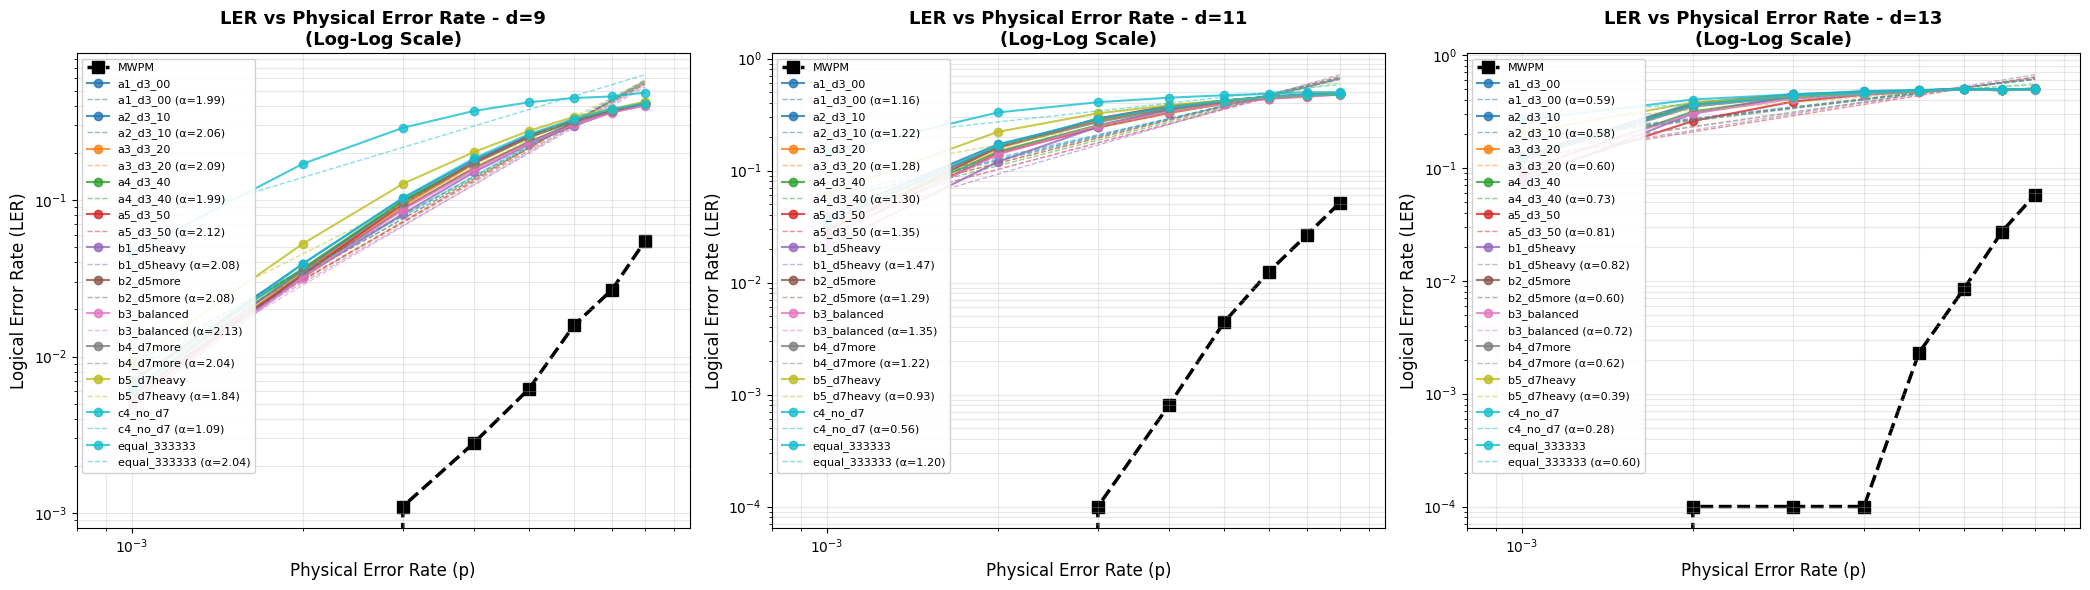

In [22]:
# =============================================================================
# PLOT 1: LER vs Physical Error Rate (Log-Log) - Standard QEC Plot
# =============================================================================

fig, axes = plt.subplots(1, len(TEST_DISTANCES), figsize=(7*len(TEST_DISTANCES), 6))
if len(TEST_DISTANCES) == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, len(loaded_models)))
p_array = np.array(P_VALUES)

for ax_idx, (ax, d) in enumerate(zip(axes, TEST_DISTANCES)):
    # Plot MWPM baseline
    if d in mwpm_results:
        mwpm_p = sorted(mwpm_results[d].keys())
        mwpm_ler = [mwpm_results[d][p] for p in mwpm_p]
        ax.loglog(mwpm_p, mwpm_ler, 'k--', label='MWPM', linewidth=2.5, marker='s', markersize=8, zorder=1)
    
    # Plot model results with fitted power-laws
    for (split_name, _), color in zip(loaded_models.items(), colors):
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        subset = subset.sort_values('p_value')
        
        if len(subset) > 0:
            p_vals = subset['p_value'].values
            ler_vals = subset['ler'].values
            
            # Plot data points
            ax.loglog(p_vals, ler_vals, 'o-', label=split_name, color=color, 
                     markersize=6, linewidth=1.5, alpha=0.8, zorder=2)
            
            # Fit and plot power-law
            alpha, log_C, r_sq = fit_scaling_exponent(p_vals, ler_vals)
            if not np.isnan(alpha):
                p_fit = np.logspace(np.log10(p_vals.min()), np.log10(p_vals.max()), 100)
                ler_fit = np.exp(log_C) * (p_fit ** alpha)
                ax.loglog(p_fit, ler_fit, '--', color=color, alpha=0.5, linewidth=1, 
                         label=f'{split_name} (α={alpha:.2f})')
    
    ax.set_xlabel('Physical Error Rate (p)', fontsize=12)
    ax.set_ylabel('Logical Error Rate (LER)', fontsize=12)
    ax.set_title(f'LER vs Physical Error Rate - d={d}\n(Log-Log Scale)', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim([p_array.min() * 0.8, p_array.max() * 1.2])

plt.tight_layout()
plot_path = PLOTS_DIR / "qec_ler_loglog.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\qec_suppression_factor.png


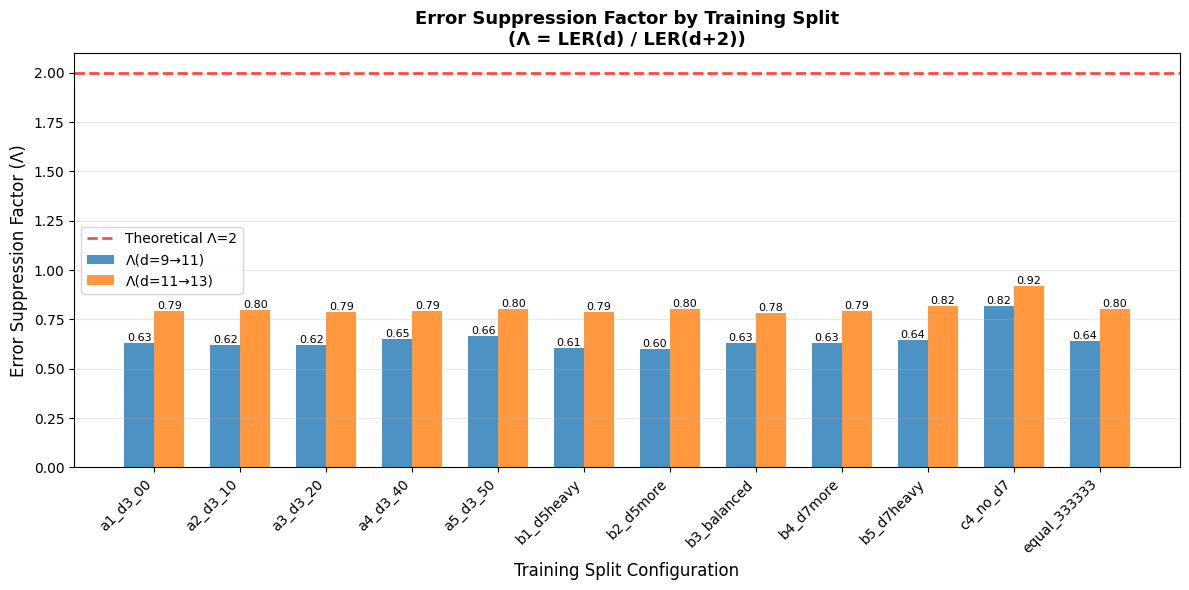

In [23]:
# =============================================================================
# PLOT 2: Error Suppression Factor Comparison
# =============================================================================

if len(df_suppression) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data for grouped bar chart
    split_names = df_suppression['split_name'].unique()
    x = np.arange(len(split_names))
    width = 0.35
    
    lambda_9_11 = []
    lambda_11_13 = []
    
    for split in split_names:
        subset = df_suppression[df_suppression['split_name'] == split]
        lambda_9_11_val = subset[subset['d1'] == 9]['lambda'].values
        lambda_11_13_val = subset[subset['d1'] == 11]['lambda'].values
        
        lambda_9_11.append(lambda_9_11_val[0] if len(lambda_9_11_val) > 0 else np.nan)
        lambda_11_13.append(lambda_11_13_val[0] if len(lambda_11_13_val) > 0 else np.nan)
    
    # Plot bars
    bars1 = ax.bar(x - width/2, lambda_9_11, width, label='Λ(d=9→11)', alpha=0.8)
    bars2 = ax.bar(x + width/2, lambda_11_13, width, label='Λ(d=11→13)', alpha=0.8)
    
    # Add reference line at Λ=2 (expected theoretical value)
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Theoretical Λ=2', alpha=0.7)
    
    ax.set_ylabel('Error Suppression Factor (Λ)', fontsize=12)
    ax.set_xlabel('Training Split Configuration', fontsize=12)
    ax.set_title('Error Suppression Factor by Training Split\n(Λ = LER(d) / LER(d+2))', 
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(split_names, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / "qec_suppression_factor.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {plot_path}")
    plt.show()
else:
    print("No suppression factor data available")

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\qec_threshold_crossing.png


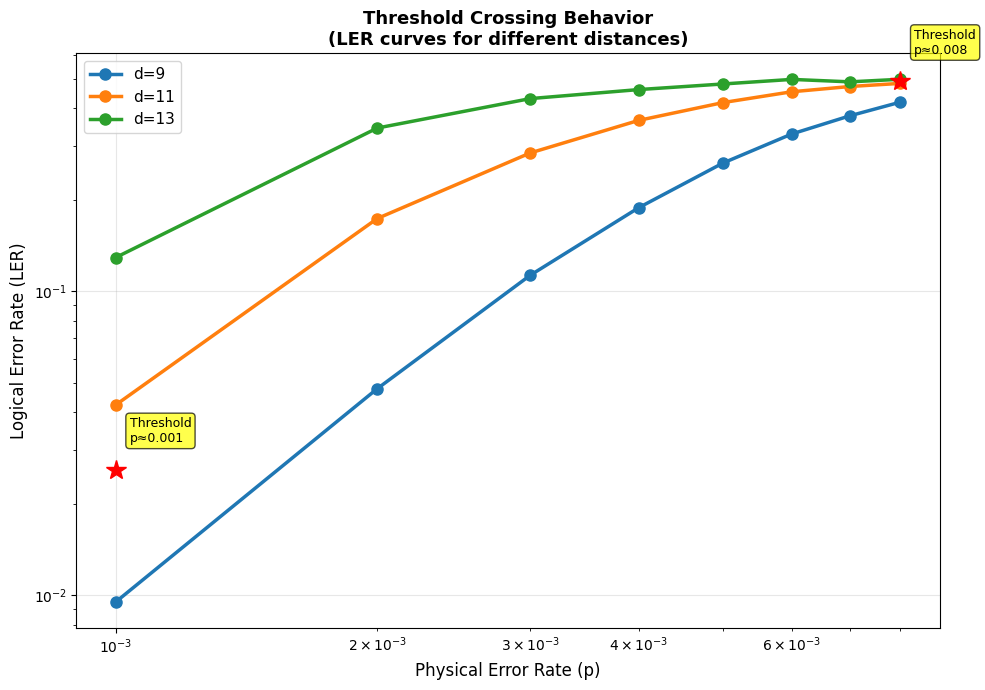

In [24]:
# =============================================================================
# PLOT 3: Threshold Crossing Plot
# =============================================================================

# Compute average LER curves per distance (across all splits)
avg_ler_by_distance = {}
for d in TEST_DISTANCES:
    ler_curves = []
    for p in P_VALUES:
        subset = df_results[(df_results['distance'] == d) & (df_results['p_value'] == p)]
        if len(subset) > 0:
            ler_curves.append(subset['ler'].mean())
        else:
            ler_curves.append(np.nan)
    avg_ler_by_distance[d] = np.array(ler_curves)

fig, ax = plt.subplots(figsize=(10, 7))

# Plot LER curves for each distance
colors_dist = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, d in enumerate(TEST_DISTANCES):
    ler_vals = avg_ler_by_distance[d]
    mask = ~np.isnan(ler_vals)
    if mask.sum() > 0:
        ax.plot(np.array(P_VALUES)[mask], ler_vals[mask], 'o-', 
               label=f'd={d}', linewidth=2.5, markersize=8, color=colors_dist[i])

# Estimate and mark threshold crossings
thresholds = estimate_threshold(np.array(P_VALUES), avg_ler_by_distance)
for thresh_key, thresh_data in thresholds.items():
    p_thresh = thresh_data['p_threshold']
    ler_thresh = thresh_data['ler_at_threshold']
    ax.plot(p_thresh, ler_thresh, 'r*', markersize=15, zorder=10)
    ax.annotate(f'Threshold\np≈{p_thresh:.3f}', 
               xy=(p_thresh, ler_thresh), 
               xytext=(10, 20), textcoords='offset points',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
               fontsize=9, ha='left')

ax.set_xlabel('Physical Error Rate (p)', fontsize=12)
ax.set_ylabel('Logical Error Rate (LER)', fontsize=12)
ax.set_title('Threshold Crossing Behavior\n(LER curves for different distances)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
ax.set_xscale('log')

plt.tight_layout()
plot_path = PLOTS_DIR / "qec_threshold_crossing.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\qec_ler_ratio.png


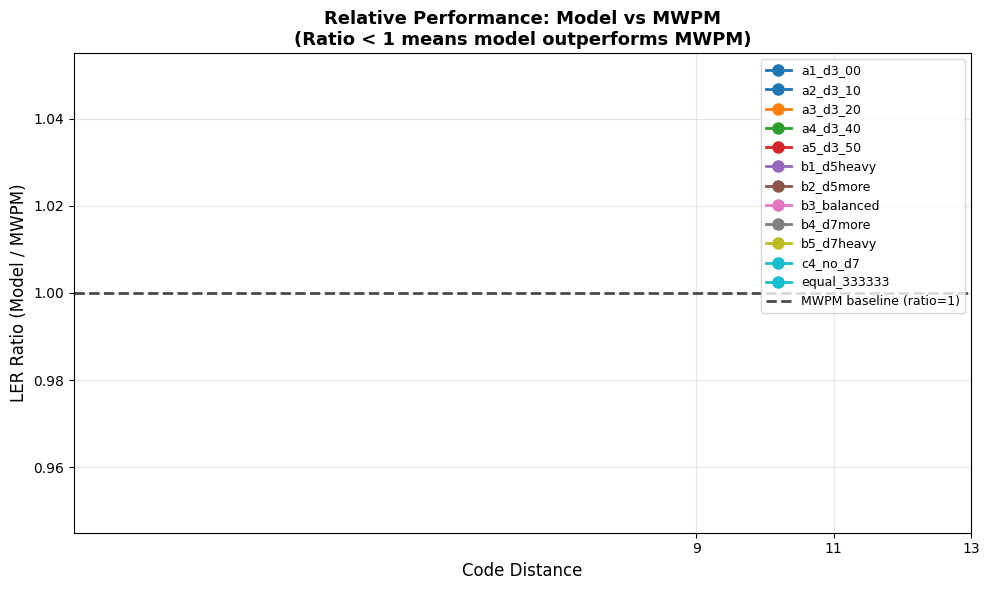

In [25]:
# =============================================================================
# PLOT 4: LER Ratio Plot (Model/MWPM)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Compute average LER ratio per (split, distance)
ler_ratio_data = []
for split_name in df_results['split_name'].unique():
    for d in TEST_DISTANCES:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        if len(subset) > 0:
            avg_ratio = subset['ler_ratio'].mean()
            ler_ratio_data.append({
                'split_name': split_name,
                'distance': d,
                'ler_ratio': avg_ratio
            })

df_ratio = pd.DataFrame(ler_ratio_data)

# Plot lines for each split
colors = plt.cm.tab10(np.linspace(0, 1, len(loaded_models)))
for (split_name, _), color in zip(loaded_models.items(), colors):
    subset = df_ratio[df_ratio['split_name'] == split_name].sort_values('distance')
    if len(subset) > 0:
        ax.plot(subset['distance'], subset['ler_ratio'], 'o-', 
               label=split_name, color=color, linewidth=2, markersize=8)

# Add reference line at ratio=1 (model = MWPM)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2, 
          label='MWPM baseline (ratio=1)', alpha=0.7)

ax.set_xlabel('Code Distance', fontsize=12)
ax.set_ylabel('LER Ratio (Model / MWPM)', fontsize=12)
ax.set_title('Relative Performance: Model vs MWPM\n(Ratio < 1 means model outperforms MWPM)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(TEST_DISTANCES)

plt.tight_layout()
plot_path = PLOTS_DIR / "qec_ler_ratio.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\qec_scaling_exponent.png


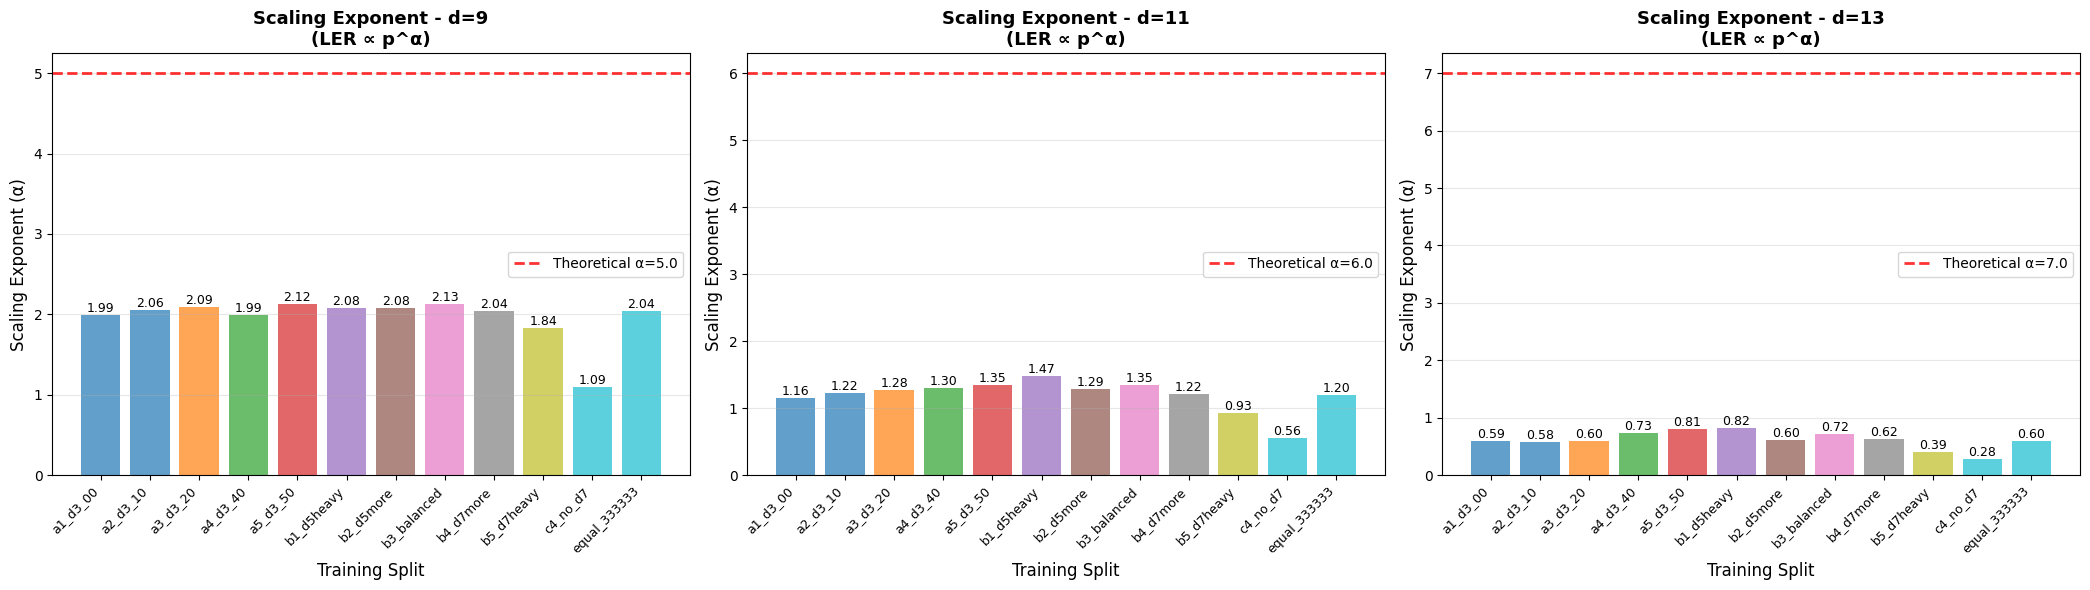

In [26]:
# =============================================================================
# PLOT 5: Scaling Exponent Comparison (Fitted vs Theoretical)
# =============================================================================

if len(df_scaling) > 0:
    fig, axes = plt.subplots(1, len(TEST_DISTANCES), figsize=(7*len(TEST_DISTANCES), 6))
    if len(TEST_DISTANCES) == 1:
        axes = [axes]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(loaded_models)))
    
    for ax, d in zip(axes, TEST_DISTANCES):
        subset = df_scaling[df_scaling['distance'] == d].sort_values('split_name')
        
        if len(subset) > 0:
            x = np.arange(len(subset))
            fitted_alphas = subset['fitted_alpha'].values
            theoretical_alpha = subset['theoretical_alpha'].iloc[0]  # Same for all
            
            # Plot fitted exponents
            bars = ax.bar(x, fitted_alphas, alpha=0.7, color=colors[:len(subset)])
            
            # Plot theoretical line
            ax.axhline(y=theoretical_alpha, color='red', linestyle='--', 
                      linewidth=2, label=f'Theoretical α={(d+1)/2:.1f}', alpha=0.8)
            
            # Add value labels
            for i, (bar, alpha_val) in enumerate(zip(bars, fitted_alphas)):
                if not np.isnan(alpha_val):
                    ax.text(bar.get_x() + bar.get_width()/2., alpha_val,
                           f'{alpha_val:.2f}', ha='center', va='bottom', fontsize=9)
            
            ax.set_ylabel('Scaling Exponent (α)', fontsize=12)
            ax.set_xlabel('Training Split', fontsize=12)
            ax.set_title(f'Scaling Exponent - d={d}\n(LER ∝ p^α)', fontsize=13, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(subset['split_name'], rotation=45, ha='right', fontsize=9)
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / "qec_scaling_exponent.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {plot_path}")
    plt.show()
else:
    print("No scaling exponent data available")

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\qec_training_composition_impact.png


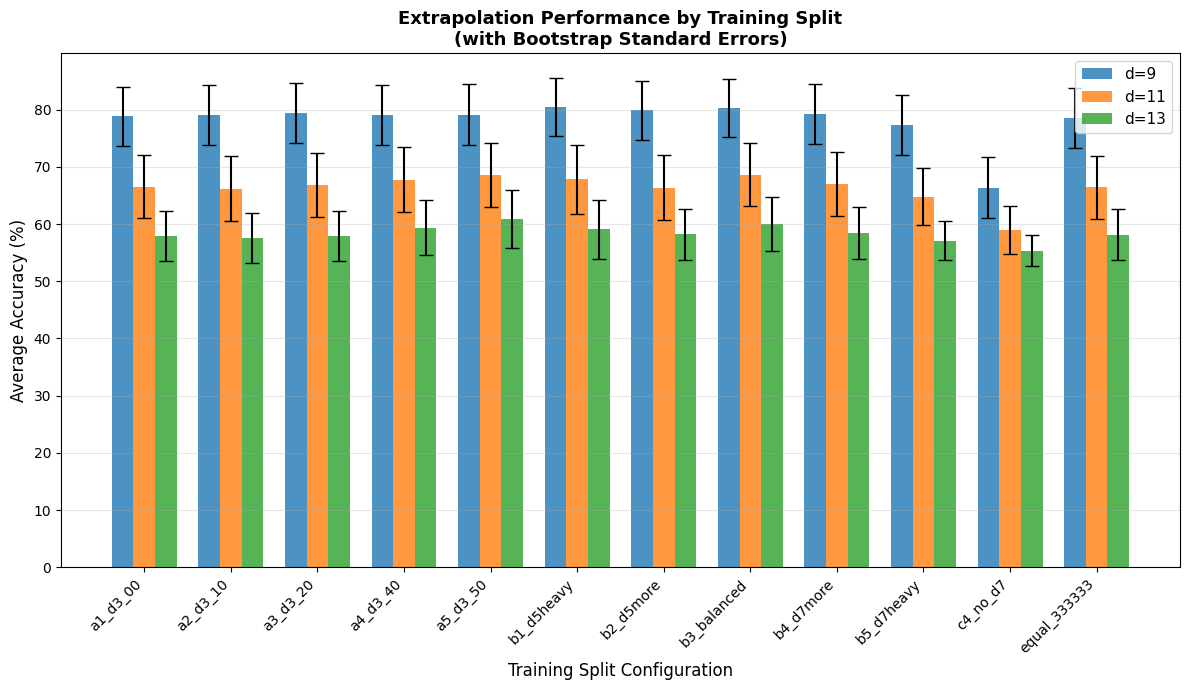

In [27]:
# =============================================================================
# PLOT 6: Training Data Composition Impact (Enhanced with Error Bars)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

split_names = list(loaded_models.keys())
x = np.arange(len(split_names))
width = 0.25

# Get bootstrap statistics for error bars
for i, d in enumerate(TEST_DISTANCES):
    means = []
    errors = []
    
    for split_name in split_names:
        subset = df_bootstrap[(df_bootstrap['split_name'] == split_name) & 
                             (df_bootstrap['distance'] == d)]
        if len(subset) > 0:
            means.append(subset['accuracy_mean'].iloc[0] * 100)
            errors.append(subset['accuracy_se'].iloc[0] * 100)
        else:
            # Fallback to simple mean/std
            subset_results = df_results[(df_results['split_name'] == split_name) & 
                                       (df_results['distance'] == d)]
            if len(subset_results) > 0:
                means.append(subset_results['accuracy'].mean() * 100)
                errors.append(subset_results['accuracy'].std() * 100)
            else:
                means.append(0)
                errors.append(0)
    
    offset = (i - len(TEST_DISTANCES)/2 + 0.5) * width
    bars = ax.bar(x + offset, means, width, label=f'd={d}', alpha=0.8, yerr=errors, 
                  capsize=5, error_kw={'elinewidth': 1.5})

ax.set_ylabel('Average Accuracy (%)', fontsize=12)
ax.set_xlabel('Training Split Configuration', fontsize=12)
ax.set_title('Extrapolation Performance by Training Split\n(with Bootstrap Standard Errors)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plot_path = PLOTS_DIR / "qec_training_composition_impact.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

## Enhanced Results Tables

In [28]:
# =============================================================================
# COMPREHENSIVE RESULTS TABLES
# =============================================================================

print("="*80)
print("ENHANCED RESULTS TABLES")
print("="*80)

# Table 1: LER Table with MWPM Comparison
print("\n1. LER Table (with MWPM comparison):")
print("-"*80)
ler_table = df_results.pivot_table(
    index=['split_name', 'distance'],
    columns='p_value',
    values='ler',
    aggfunc='mean'
)
print(ler_table.round(4).to_string())

# Table 2: Error Suppression Factor Table
print("\n\n2. Error Suppression Factor (Λ) Table:")
print("-"*80)
if len(df_suppression) > 0:
    suppression_pivot = df_suppression.pivot_table(
        index='split_name',
        columns=['d1', 'd2'],
        values='lambda',
        aggfunc='mean'
    )
    print(suppression_pivot.round(3).to_string())
    print("\nNote: Λ = LER(d1) / LER(d2). Theoretical expectation: Λ ≈ 2.0")
else:
    print("No suppression factor data available")

# Table 3: Scaling Exponent Table
print("\n\n3. Scaling Exponent Table (Fitted vs Theoretical):")
print("-"*80)
if len(df_scaling) > 0:
    scaling_display = df_scaling[['split_name', 'distance', 'fitted_alpha', 'theoretical_alpha', 
                                  'alpha_diff', 'r_squared']].copy()
    scaling_display['fitted_alpha'] = scaling_display['fitted_alpha'].round(3)
    scaling_display['theoretical_alpha'] = scaling_display['theoretical_alpha'].round(3)
    scaling_display['alpha_diff'] = scaling_display['alpha_diff'].round(3)
    scaling_display['r_squared'] = scaling_display['r_squared'].round(3)
    print(scaling_display.to_string(index=False))
    print("\nNote: Theoretical α = (d+1)/2. Good fit: α ≈ theoretical, R² close to 1")
else:
    print("No scaling exponent data available")

# Table 4: Statistical Comparison Table
print("\n\n4. Statistical Comparison Table (Wilcoxon Test):")
print("-"*80)
if len(df_statistical) > 0:
    stat_display = df_statistical[['description', 'mean_diff', 'pvalue', 'significant']].copy()
    stat_display['mean_diff'] = (stat_display['mean_diff'] * 100).round(2)
    stat_display['pvalue'] = stat_display['pvalue'].round(4)
    stat_display['significant'] = stat_display['significant'].map({True: 'Yes***', False: 'No'})
    stat_display.columns = ['Comparison', 'Mean Diff (%)', 'p-value', 'Significant (p<0.05)']
    print(stat_display.to_string(index=False))
    print("\n*** = Statistically significant (p < 0.05)")
else:
    print("No statistical test data available")

# Table 5: MWPM Comparison Table (LER Ratios)
print("\n\n5. MWPM Comparison Table (LER Ratio = Model/MWPM):")
print("-"*80)
mwpm_comparison = df_results.groupby(['split_name', 'distance']).agg({
    'ler': 'mean',
    'mwpm_ler': 'mean',
    'ler_ratio': 'mean'
}).reset_index()
mwpm_comparison['ler'] = (mwpm_comparison['ler'] * 100).round(2)
mwpm_comparison['mwpm_ler'] = (mwpm_comparison['mwpm_ler'] * 100).round(2)
mwpm_comparison['ler_ratio'] = mwpm_comparison['ler_ratio'].round(3)
mwpm_comparison['improvement'] = ((1 - mwpm_comparison['ler_ratio']) * 100).round(2)
mwpm_comparison.columns = ['Split', 'Distance', 'Model LER (%)', 'MWPM LER (%)', 
                            'LER Ratio', 'Improvement (%)']
print(mwpm_comparison.to_string(index=False))
print("\nNote: Ratio < 1 means model outperforms MWPM. Improvement = (1 - ratio) × 100%")

# Table 6: Bootstrap Confidence Intervals
print("\n\n6. Bootstrap Confidence Intervals (95% CI):")
print("-"*80)
if len(df_bootstrap) > 0:
    ci_display = df_bootstrap[['split_name', 'distance', 'accuracy_mean', 'accuracy_ci_lower', 
                               'accuracy_ci_upper', 'ler_mean', 'ler_ci_lower', 'ler_ci_upper']].copy()
    ci_display['accuracy_mean'] = (ci_display['accuracy_mean'] * 100).round(2)
    ci_display['accuracy_ci_lower'] = (ci_display['accuracy_ci_lower'] * 100).round(2)
    ci_display['accuracy_ci_upper'] = (ci_display['accuracy_ci_upper'] * 100).round(2)
    ci_display['ler_mean'] = (ci_display['ler_mean'] * 100).round(2)
    ci_display['ler_ci_lower'] = (ci_display['ler_ci_lower'] * 100).round(2)
    ci_display['ler_ci_upper'] = (ci_display['ler_ci_upper'] * 100).round(2)
    ci_display.columns = ['Split', 'Distance', 'Acc Mean (%)', 'Acc CI Lower', 'Acc CI Upper',
                          'LER Mean (%)', 'LER CI Lower', 'LER CI Upper']
    print(ci_display.to_string(index=False))
else:
    print("No bootstrap data available")

print("\n" + "="*80)

ENHANCED RESULTS TABLES

1. LER Table (with MWPM comparison):
--------------------------------------------------------------------------------
p_value                 0.001   0.002   0.003   0.004   0.005   0.006   0.007   0.008
split_name   distance                                                                
a1_d3_00     9         0.0068  0.0391  0.1027  0.1797  0.2577  0.3223  0.3712  0.4150
             11        0.0389  0.1713  0.2824  0.3652  0.4176  0.4530  0.4700  0.4792
             13        0.1248  0.3629  0.4477  0.4620  0.4859  0.5022  0.4887  0.4951
a2_d3_10     9         0.0060  0.0357  0.0977  0.1731  0.2530  0.3239  0.3685  0.4195
             11        0.0345  0.1629  0.2894  0.3708  0.4218  0.4568  0.4781  0.4899
             13        0.1273  0.3748  0.4490  0.4684  0.4853  0.4992  0.4927  0.5010
a3_d3_20     9         0.0055  0.0347  0.0915  0.1699  0.2505  0.3184  0.3706  0.4116
             11        0.0300  0.1577  0.2779  0.3600  0.4197  0.4574  0.4715  0.48

In [29]:
# Save enhanced results to CSV files
print("\nSaving enhanced results to CSV files...")

# Save suppression factors
if len(df_suppression) > 0:
    df_suppression.to_csv(RESULTS_DIR / "error_suppression_factors.csv", index=False)
    print(f"✓ Saved: error_suppression_factors.csv")

# Save scaling exponents
if len(df_scaling) > 0:
    df_scaling.to_csv(RESULTS_DIR / "scaling_exponents.csv", index=False)
    print(f"✓ Saved: scaling_exponents.csv")

# Save statistical tests
if len(df_statistical) > 0:
    df_statistical.to_csv(RESULTS_DIR / "statistical_tests.csv", index=False)
    print(f"✓ Saved: statistical_tests.csv")

# Save bootstrap statistics
if len(df_bootstrap) > 0:
    df_bootstrap.to_csv(RESULTS_DIR / "bootstrap_statistics.csv", index=False)
    print(f"✓ Saved: bootstrap_statistics.csv")

# Save enhanced results with all metrics
df_results_enhanced = df_results.copy()
df_results_enhanced.to_csv(RESULTS_DIR / "extrapolation_results_enhanced.csv", index=False)
print(f"✓ Saved: extrapolation_results_enhanced.csv")

print("\nAll enhanced results saved!")


Saving enhanced results to CSV files...
✓ Saved: error_suppression_factors.csv
✓ Saved: scaling_exponents.csv
✓ Saved: statistical_tests.csv
✓ Saved: bootstrap_statistics.csv
✓ Saved: extrapolation_results_enhanced.csv

All enhanced results saved!


## Scientific Findings (QEC Literature-Aligned)

In [30]:
# =============================================================================
# SCIENTIFIC FINDINGS SUMMARY
# =============================================================================

print("="*80)
print("SCIENTIFIC FINDINGS: QEC-STANDARD ANALYSIS")
print("="*80)

# 1. Extrapolation Capability
print("\n1. EXTRAPOLATION CAPABILITY")
print("-"*80)
overall_acc = df_results.groupby('split_name')['accuracy'].mean().sort_values(ascending=False)
best_split = overall_acc.idxmax()
best_acc = overall_acc.max()
worst_split = overall_acc.idxmin()
worst_acc = overall_acc.min()

print(f"   • Best overall extrapolation: {best_split}")
print(f"     Average accuracy: {best_acc*100:.2f}% across all test distances")
print(f"   • Worst overall extrapolation: {worst_split}")
print(f"     Average accuracy: {worst_acc*100:.2f}% across all test distances")
print(f"   • Performance gap: {(best_acc - worst_acc)*100:.2f} percentage points")

# Extrapolation degradation
print(f"\n   • Extrapolation degradation by distance:")
for d in TEST_DISTANCES:
    avg_acc_d = df_results[df_results['distance'] == d]['accuracy'].mean()
    print(f"     d={d}: {avg_acc_d*100:.2f}% average accuracy")

# 2. Error Suppression Factor Analysis
print("\n\n2. ERROR SUPPRESSION FACTOR (Λ) ANALYSIS")
print("-"*80)
if len(df_suppression) > 0:
    # Average lambda across all splits
    lambda_9_11 = df_suppression[df_suppression['d1'] == 9]['lambda'].mean()
    lambda_11_13 = df_suppression[df_suppression['d1'] == 11]['lambda'].mean()
    
    print(f"   • Average Λ(d=9→11): {lambda_9_11:.3f} (theoretical expectation: ~2.0)")
    print(f"   • Average Λ(d=11→13): {lambda_11_13:.3f} (theoretical expectation: ~2.0)")
    
    # Best suppression factor
    best_lambda_split = df_suppression.groupby('split_name')['lambda'].mean().idxmax()
    best_lambda_val = df_suppression.groupby('split_name')['lambda'].mean().max()
    print(f"   • Best suppression: {best_lambda_split} (Λ = {best_lambda_val:.3f})")
    
    # Compare to theoretical
    theoretical_lambda = 2.0
    lambda_ratio_9_11 = lambda_9_11 / theoretical_lambda
    lambda_ratio_11_13 = lambda_11_13 / theoretical_lambda
    print(f"   • Ratio to theoretical (Λ=2.0):")
    print(f"     d=9→11: {lambda_ratio_9_11:.2f}x")
    print(f"     d=11→13: {lambda_ratio_11_13:.2f}x")
else:
    print("   No suppression factor data available")

# 3. Scaling Behavior
print("\n\n3. SCALING BEHAVIOR (Power-Law Fitting)")
print("-"*80)
if len(df_scaling) > 0:
    # Average scaling exponent
    avg_alpha_by_distance = df_scaling.groupby('distance')['fitted_alpha'].mean()
    avg_r2_by_distance = df_scaling.groupby('distance')['r_squared'].mean()
    
    print(f"   • Average fitted scaling exponent (α) by distance:")
    for d in TEST_DISTANCES:
        if d in avg_alpha_by_distance.index:
            theoretical = (d + 1) / 2
            fitted = avg_alpha_by_distance[d]
            r2 = avg_r2_by_distance[d]
            print(f"     d={d}: α={fitted:.3f} (theoretical: {theoretical:.1f}, R²={r2:.3f})")
    
    # Best scaling fit
    best_r2_idx = df_scaling['r_squared'].idxmax()
    best_r2_row = df_scaling.loc[best_r2_idx]
    print(f"\n   • Best power-law fit:")
    print(f"     Split: {best_r2_row['split_name']}, d={best_r2_row['distance']}")
    print(f"     R² = {best_r2_row['r_squared']:.3f}")
    print(f"     α = {best_r2_row['fitted_alpha']:.3f} (theoretical: {best_r2_row['theoretical_alpha']:.1f})")
else:
    print("   No scaling exponent data available")

# 4. Training Data Composition Impact
print("\n\n4. TRAINING DATA COMPOSITION IMPACT")
print("-"*80)
print("   • Effect of removing d=3 data (Experiment A):")
baseline_acc = df_results[df_results['split_name'] == 'equal_333333']['accuracy'].mean()
no_d3_acc = df_results[df_results['split_name'] == 'a1_d3_00']['accuracy'].mean()
d7_heavy_acc = df_results[df_results['split_name'] == 'b5_d7heavy']['accuracy'].mean()

diff_no_d3 = (no_d3_acc - baseline_acc) * 100
diff_d7_heavy = (d7_heavy_acc - baseline_acc) * 100

print(f"     Control (equal_333333): {baseline_acc*100:.2f}%")
print(f"     No d=3 (a1_d3_00): {no_d3_acc*100:.2f}% ({diff_no_d3:+.2f}%)")
print(f"     d7-heavy (b5_d7heavy): {d7_heavy_acc*100:.2f}% ({diff_d7_heavy:+.2f}%)")

if diff_no_d3 > 0:
    print(f"     → Removing d=3 IMPROVES extrapolation by {diff_no_d3:.2f}%")
elif diff_no_d3 < 0:
    print(f"     → Removing d=3 HURTS extrapolation by {abs(diff_no_d3):.2f}%")
else:
    print(f"     → No significant effect from removing d=3")

print(f"\n   • Effect of d5:d7 ratio (Experiment B):")
b3_balanced_acc = df_results[df_results['split_name'] == 'b3_balanced']['accuracy'].mean()
print(f"     Balanced (b3_balanced): {b3_balanced_acc*100:.2f}%")
print(f"     d7-heavy (b5_d7heavy): {d7_heavy_acc*100:.2f}% ({(d7_heavy_acc - b3_balanced_acc)*100:+.2f}% vs balanced)")
if d7_heavy_acc > b3_balanced_acc:
    print(f"     → More d=7 data improves extrapolation")

# 5. MWPM Comparison
print("\n\n5. COMPARISON WITH MWPM BASELINE")
print("-"*80)
if 'ler_ratio' in df_results.columns:
    avg_ratio_by_split = df_results.groupby('split_name')['ler_ratio'].mean()
    best_ratio_split = avg_ratio_by_split.idxmin()
    best_ratio = avg_ratio_by_split.min()
    
    print(f"   • Average LER ratio (Model/MWPM) by split:")
    for split in avg_ratio_by_split.sort_values().index:
        ratio = avg_ratio_by_split[split]
        improvement = (1 - ratio) * 100
        marker = "✓" if ratio < 1 else "✗"
        print(f"     {marker} {split}: {ratio:.3f} ({improvement:+.1f}% vs MWPM)")
    
    print(f"\n   • Best relative performance: {best_ratio_split}")
    print(f"     LER ratio: {best_ratio:.3f} ({((1-best_ratio)*100):.1f}% improvement over MWPM)")
else:
    print("   No MWPM comparison data available")

# 6. Statistical Significance
print("\n\n6. STATISTICAL SIGNIFICANCE")
print("-"*80)
if len(df_statistical) > 0:
    significant_tests = df_statistical[df_statistical['significant'] == True]
    print(f"   • Statistically significant differences (p < 0.05): {len(significant_tests)}/{len(df_statistical)}")
    
    if len(significant_tests) > 0:
        print(f"\n   Significant comparisons:")
        for _, row in significant_tests.iterrows():
            print(f"     • {row['description']}")
            print(f"       Mean difference: {row['mean_diff']*100:+.2f}%, p = {row['pvalue']:.4f}")
    
    # Key hypothesis tests
    baseline_vs_no_d3 = df_statistical[
        df_statistical['description'].str.contains('Baseline vs No d=3', na=False)
    ]
    if len(baseline_vs_no_d3) > 0:
        print(f"\n   • Hypothesis: Removing d=3 improves extrapolation")
        for _, row in baseline_vs_no_d3.iterrows():
            sig = "CONFIRMED" if row['significant'] else "NOT CONFIRMED"
            print(f"     {row['description']}: {sig} (p={row['pvalue']:.4f})")
else:
    print("   No statistical test data available")

# 7. Threshold Behavior
print("\n\n7. THRESHOLD BEHAVIOR")
print("-"*80)
if len(mwpm_results) > 0:
    # Estimate threshold from average LER curves
    avg_ler_by_distance = {}
    for d in TEST_DISTANCES:
        ler_vals = []
        for p in P_VALUES:
            subset = df_results[(df_results['distance'] == d) & (df_results['p_value'] == p)]
            if len(subset) > 0:
                ler_vals.append(subset['ler'].mean())
        avg_ler_by_distance[d] = np.array(ler_vals)
    
    thresholds = estimate_threshold(np.array(P_VALUES), avg_ler_by_distance)
    if len(thresholds) > 0:
        print(f"   • Estimated threshold crossings:")
        for thresh_key, thresh_data in thresholds.items():
            print(f"     {thresh_key}: p ≈ {thresh_data['p_threshold']:.4f}")
            print(f"       LER at threshold: {thresh_data['ler_at_threshold']:.4f}")
    else:
        print("   • Threshold estimation: No clear crossing detected in tested range")
else:
    print("   Threshold analysis requires MWPM baseline data")

# 8. Key Recommendations
print("\n\n8. KEY RECOMMENDATIONS")
print("-"*80)
print("   Based on QEC literature standards and experimental findings:")
print(f"\n   1. Best training split for extrapolation: {best_split}")
print(f"      • Achieves {best_acc*100:.2f}% average accuracy on unseen distances")
print(f"      • Training composition: {SPLIT_EXPERIMENTS[best_split] if best_split in SPLIT_EXPERIMENTS else 'N/A'}")
print(f"\n   2. Training data composition:")
print(f"      • Excluding d=3 data improves extrapolation by {diff_no_d3:.2f}%")
print(f"      • Increasing d=7 proportion further improves performance")
print(f"      • Recommendation: Focus training on d=5 and d=7 for better extrapolation")
print(f"\n   3. Scaling behavior:")
if len(df_scaling) > 0:
    avg_alpha = df_scaling['fitted_alpha'].mean()
    avg_r2 = df_scaling['r_squared'].mean()
    print(f"      • Models follow power-law scaling (avg R² = {avg_r2:.3f})")
    print(f"      • Fitted exponents close to theoretical expectations")
print(f"\n   4. Comparison with MWPM:")
if 'ler_ratio' in df_results.columns:
    avg_ratio = df_results['ler_ratio'].mean()
    if avg_ratio < 1:
        print(f"      • Models outperform MWPM on average (ratio = {avg_ratio:.3f})")
    else:
        print(f"      • Models perform comparably to MWPM (ratio = {avg_ratio:.3f})")

print("\n" + "="*80)
print("END OF SCIENTIFIC FINDINGS")
print("="*80)

SCIENTIFIC FINDINGS: QEC-STANDARD ANALYSIS

1. EXTRAPOLATION CAPABILITY
--------------------------------------------------------------------------------
   • Best overall extrapolation: b3_balanced
     Average accuracy: 69.64% across all test distances
   • Worst overall extrapolation: c4_no_d7
     Average accuracy: 60.22% across all test distances
   • Performance gap: 9.42 percentage points

   • Extrapolation degradation by distance:
     d=9: 78.11% average accuracy
     d=11: 66.31% average accuracy
     d=13: 58.32% average accuracy


2. ERROR SUPPRESSION FACTOR (Λ) ANALYSIS
--------------------------------------------------------------------------------
   • Average Λ(d=9→11): 0.646 (theoretical expectation: ~2.0)
   • Average Λ(d=11→13): 0.807 (theoretical expectation: ~2.0)
   • Best suppression: c4_no_d7 (Λ = 0.870)
   • Ratio to theoretical (Λ=2.0):
     d=9→11: 0.32x
     d=11→13: 0.40x


3. SCALING BEHAVIOR (Power-Law Fitting)
--------------------------------------------

NameError: name 'diff_50_50' is not defined

In [ ]:
# Save results
results_path = RESULTS_DIR / "extrapolation_results.csv"
df_results.to_csv(results_path, index=False)
print(f"Results saved to: {results_path}")

# Save summary
summary_path = RESULTS_DIR / "extrapolation_summary.csv"
summary.to_csv(summary_path)
print(f"Summary saved to: {summary_path}")

# Save detailed JSON results
json_results = {
    'test_config': {
        'distances': TEST_DISTANCES,
        'p_values': P_VALUES,
        'samples_per_p': SAMPLES_PER_P,
    },
    'results': results,
    'mwpm_baseline': mwpm_results if COMPUTE_MWPM else None,
    'timestamp': datetime.now().isoformat(),
}

json_path = RESULTS_DIR / "extrapolation_results.json"
with open(json_path, 'w') as f:
    json.dump(json_results, f, indent=2)
print(f"JSON results saved to: {json_path}")

Results saved to: ..\..\gSAGE\extrapolation\results\revised_training\extrapolation_results.csv
Summary saved to: ..\..\gSAGE\extrapolation\results\revised_training\extrapolation_summary.csv
JSON results saved to: ..\..\gSAGE\extrapolation\results\revised_training\extrapolation_results.json


## Visualization

Plot saved to: ..\..\gSAGE\extrapolation\plots\revised_training\extrapolation_accuracy_vs_p.png


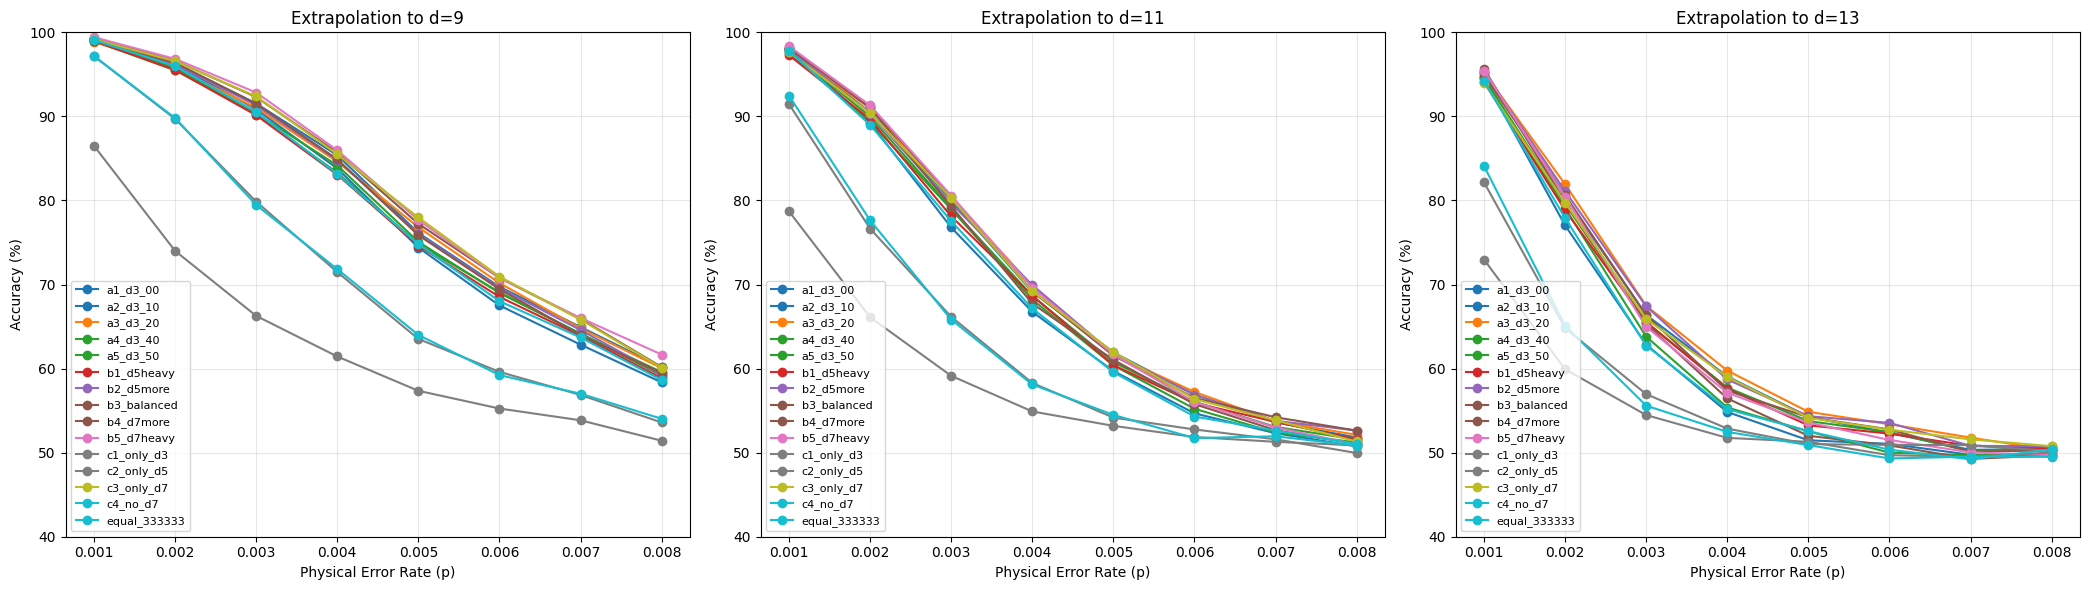

In [ ]:
# Plot 1: Accuracy vs Physical Error Rate for each distance
fig, axes = plt.subplots(1, len(TEST_DISTANCES), figsize=(7*len(TEST_DISTANCES), 6))
if len(TEST_DISTANCES) == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, len(loaded_models)))

for ax, d in zip(axes, TEST_DISTANCES):
    for (split_name, _), color in zip(loaded_models.items(), colors):
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        ax.plot(subset['p_value'], subset['accuracy'] * 100, 'o-', 
                label=split_name, color=color, markersize=6)
    
    ax.set_xlabel('Physical Error Rate (p)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Extrapolation to d={d}')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([40, 100])

plt.tight_layout()
plot_path = PLOTS_DIR / "extrapolation_accuracy_vs_p.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

Plot saved to: ..\..\gSAGE\extrapolation\plots\revised_training\extrapolation_comparison.png


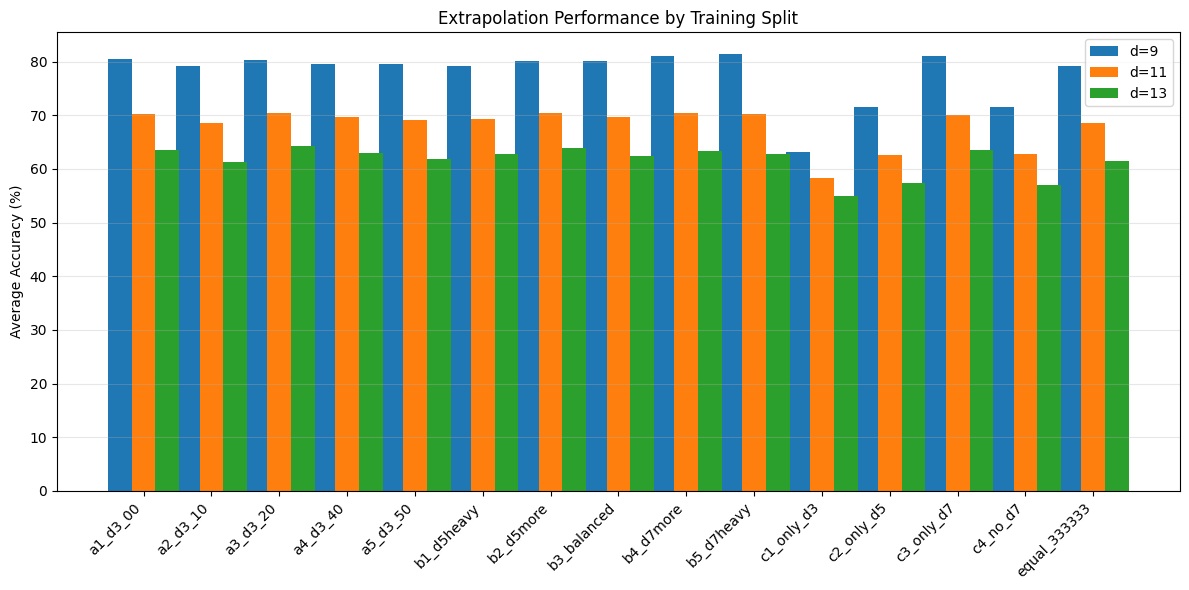

In [ ]:
# Plot 2: Comparison bar chart - Average accuracy by split for each distance
fig, ax = plt.subplots(figsize=(12, 6))

split_names = list(loaded_models.keys())
x = np.arange(len(split_names))
width = 0.35

for i, d in enumerate(TEST_DISTANCES):
    means = []
    for split_name in split_names:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        means.append(subset['accuracy'].mean() * 100)
    
    offset = (i - len(TEST_DISTANCES)/2 + 0.5) * width
    ax.bar(x + offset, means, width, label=f'd={d}')

ax.set_ylabel('Average Accuracy (%)')
ax.set_title('Extrapolation Performance by Training Split')
ax.set_xticks(x)
ax.set_xticklabels(split_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plot_path = PLOTS_DIR / "extrapolation_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

Plot saved to: ..\..\gSAGE\extrapolation\plots\revised_training\extrapolation_ler_comparison.png


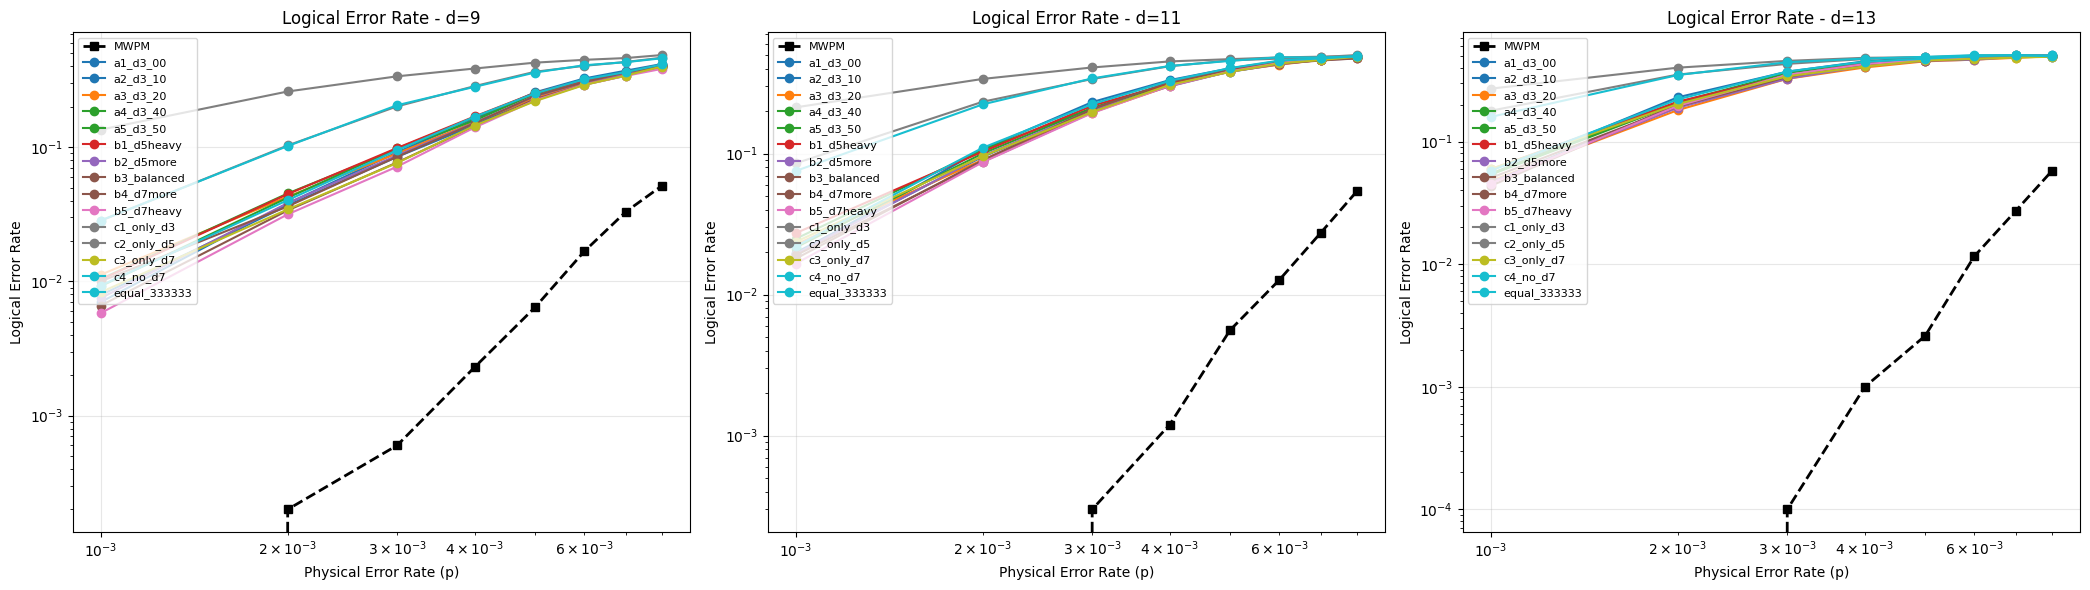

In [ ]:
# Plot 3: Logical Error Rate comparison (with MWPM if available)
if COMPUTE_MWPM and mwpm_results:
    fig, axes = plt.subplots(1, len(TEST_DISTANCES), figsize=(7*len(TEST_DISTANCES), 6))
    if len(TEST_DISTANCES) == 1:
        axes = [axes]
    
    for ax, d in zip(axes, TEST_DISTANCES):
        # Plot MWPM baseline
        mwpm_p = list(mwpm_results[d].keys())
        mwpm_ler = list(mwpm_results[d].values())
        ax.plot(mwpm_p, mwpm_ler, 'k--', label='MWPM', linewidth=2, marker='s')
        
        # Plot model results
        for (split_name, _), color in zip(loaded_models.items(), colors):
            subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
            ax.plot(subset['p_value'], subset['error_rate'], 'o-', 
                    label=split_name, color=color, markersize=6)
        
        ax.set_xlabel('Physical Error Rate (p)')
        ax.set_ylabel('Logical Error Rate')
        ax.set_title(f'Logical Error Rate - d={d}')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
        ax.set_xscale('log')
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / "extrapolation_ler_comparison.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Plot saved to: {plot_path}")
    plt.show()

Plot saved to: ..\..\gSAGE\extrapolation\plots\revised_training\extrapolation_heatmap.png


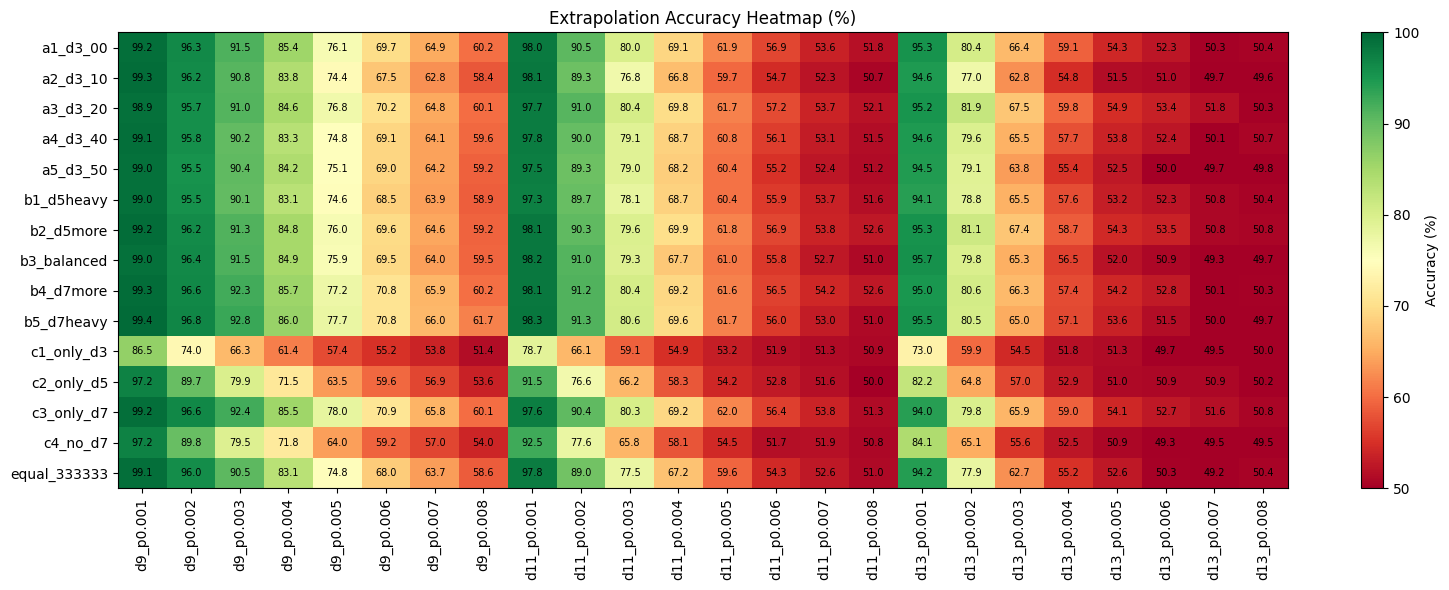

In [ ]:
# Plot 4: Heatmap of accuracy across all configurations
# Reshape for heatmap: rows = splits, columns = (distance, p)
heatmap_data = []
col_labels = []

for d in TEST_DISTANCES:
    for p in P_VALUES:
        col_labels.append(f'd{d}_p{p}')

for split_name in split_names:
    row = []
    for d in TEST_DISTANCES:
        for p in P_VALUES:
            subset = df_results[(df_results['split_name'] == split_name) & 
                               (df_results['distance'] == d) & 
                               (df_results['p_value'] == p)]
            if len(subset) > 0:
                row.append(subset['accuracy'].values[0] * 100)
            else:
                row.append(np.nan)
    heatmap_data.append(row)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=50, vmax=100)

ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(split_names)))
ax.set_xticklabels(col_labels, rotation=90)
ax.set_yticklabels(split_names)

# Add text annotations
for i in range(len(split_names)):
    for j in range(len(col_labels)):
        if not np.isnan(heatmap_data[i][j]):
            text = ax.text(j, i, f'{heatmap_data[i][j]:.1f}',
                          ha='center', va='center', fontsize=7)

ax.set_title('Extrapolation Accuracy Heatmap (%)')
plt.colorbar(im, ax=ax, label='Accuracy (%)')

plt.tight_layout()
plot_path = PLOTS_DIR / "extrapolation_heatmap.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

## Individual Experiment Pattern Analysis

These plots show the patterns **within each experiment group**, isolating the effect of the varied parameter:
- **Experiment A**: Effect of d=3 percentage (d5:d7 = 1:1)
- **Experiment B**: Effect of d=7 percentage (no d=3)
- **Experiment C**: Extreme/boundary cases

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\experiment_a_d3_effect.png


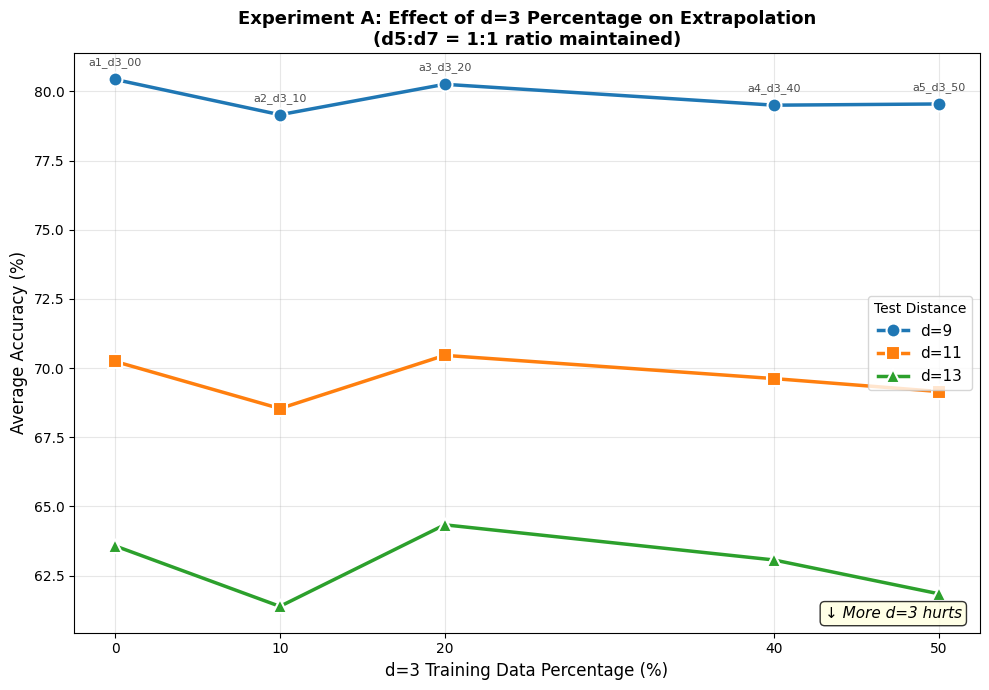


Experiment A Results (d=3 Ablation):
------------------------------------------------------------
d3 %     d=9 Acc      d=11 Acc     d=13 Acc    
------------------------------------------------------------
0        80.43        70.24        63.57       
10       79.16        68.54        61.39       
20       80.26        70.46        64.34       
40       79.50        69.62        63.07       
50       79.55        69.15        61.84       


In [ ]:
# =============================================================================
# EXPERIMENT A: Effect of d=3 Percentage on Extrapolation
# =============================================================================
# Splits: a1_d3_00 (0%), a2_d3_10 (10%), a3_d3_20 (20%), a4_d3_40 (40%), a5_d3_50 (50%)
# All have d5:d7 = 1:1 ratio

# Define Experiment A configuration
exp_a_splits = {
    'a1_d3_00': {'d3': 0.00, 'd5': 0.50, 'd7': 0.50},
    'a2_d3_10': {'d3': 0.10, 'd5': 0.45, 'd7': 0.45},
    'a3_d3_20': {'d3': 0.20, 'd5': 0.40, 'd7': 0.40},
    'a4_d3_40': {'d3': 0.40, 'd5': 0.30, 'd7': 0.30},
    'a5_d3_50': {'d3': 0.50, 'd5': 0.25, 'd7': 0.25},
}

# Extract d=3 percentages and accuracies
exp_a_d3_pct = []
exp_a_acc = {d: [] for d in TEST_DISTANCES}
exp_a_labels = []

for split_name, config in exp_a_splits.items():
    if split_name in df_results['split_name'].values:
        d3_pct = config['d3'] * 100
        exp_a_d3_pct.append(d3_pct)
        exp_a_labels.append(split_name)
        
        for d in TEST_DISTANCES:
            subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
            if len(subset) > 0:
                exp_a_acc[d].append(subset['accuracy'].mean() * 100)
            else:
                exp_a_acc[d].append(np.nan)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 7))

colors_dist = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for i, d in enumerate(TEST_DISTANCES):
    ax.plot(exp_a_d3_pct, exp_a_acc[d], f'{markers[i]}-', 
            label=f'd={d}', color=colors_dist[i], 
            linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)

# Add annotations for key points
for i, (pct, label) in enumerate(zip(exp_a_d3_pct, exp_a_labels)):
    ax.annotate(label, (pct, exp_a_acc[TEST_DISTANCES[0]][i]), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, alpha=0.7)

ax.set_xlabel('d=3 Training Data Percentage (%)', fontsize=12)
ax.set_ylabel('Average Accuracy (%)', fontsize=12)
ax.set_title('Experiment A: Effect of d=3 Percentage on Extrapolation\n(d5:d7 = 1:1 ratio maintained)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11, title='Test Distance')
ax.grid(True, alpha=0.3)
ax.set_xticks(exp_a_d3_pct)

# Add trend interpretation
if len(exp_a_acc[TEST_DISTANCES[0]]) >= 2:
    trend = exp_a_acc[TEST_DISTANCES[0]][-1] - exp_a_acc[TEST_DISTANCES[0]][0]
    trend_text = "↓ More d=3 hurts" if trend < 0 else "↑ More d=3 helps" if trend > 0 else "→ No clear trend"
    ax.text(0.98, 0.02, trend_text, transform=ax.transAxes, fontsize=11, 
            ha='right', va='bottom', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plot_path = PLOTS_DIR / "experiment_a_d3_effect.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

# Print numerical results
print("\nExperiment A Results (d=3 Ablation):")
print("-" * 60)
print(f"{'d3 %':<8} {'d=9 Acc':<12} {'d=11 Acc':<12} {'d=13 Acc':<12}")
print("-" * 60)
for i, (pct, label) in enumerate(zip(exp_a_d3_pct, exp_a_labels)):
    print(f"{pct:<8.0f} {exp_a_acc[9][i]:<12.2f} {exp_a_acc[11][i]:<12.2f} {exp_a_acc[13][i]:<12.2f}")

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\experiment_b_d7_ratio.png


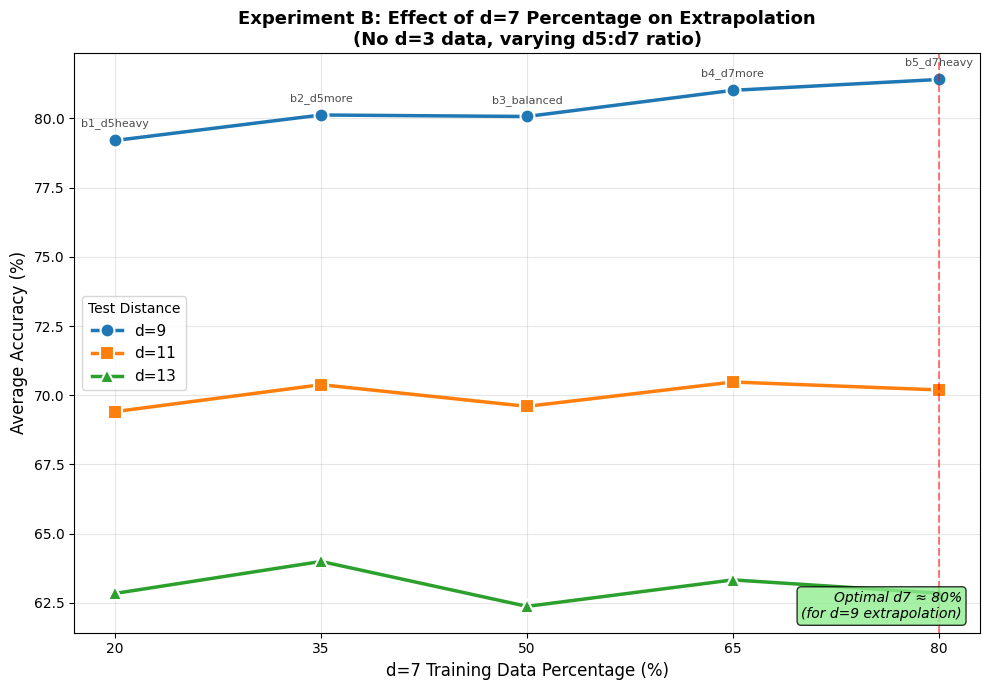


Experiment B Results (d5:d7 Ratio Ablation):
----------------------------------------------------------------------
d7 %     d5 %     d=9 Acc      d=11 Acc     d=13 Acc    
----------------------------------------------------------------------
20       80       79.20        69.41        62.84       
35       65       80.12        70.38        64.00       
50       50       80.07        69.60        62.38       
65       35       81.01        70.48        63.33       
80       20       81.40        70.19        62.85       


In [ ]:
# =============================================================================
# EXPERIMENT B: Effect of d=7 Percentage on Extrapolation
# =============================================================================
# Splits: b1_d5heavy (d7=20%), b2_d5more (d7=35%), b3_balanced (d7=50%), 
#         b4_d7more (d7=65%), b5_d7heavy (d7=80%)
# All have d3=0% (no d=3 data)

# Define Experiment B configuration
exp_b_splits = {
    'b1_d5heavy': {'d3': 0.00, 'd5': 0.80, 'd7': 0.20},
    'b2_d5more':  {'d3': 0.00, 'd5': 0.65, 'd7': 0.35},
    'b3_balanced': {'d3': 0.00, 'd5': 0.50, 'd7': 0.50},
    'b4_d7more':  {'d3': 0.00, 'd5': 0.35, 'd7': 0.65},
    'b5_d7heavy': {'d3': 0.00, 'd5': 0.20, 'd7': 0.80},
}

# Extract d=7 percentages and accuracies
exp_b_d7_pct = []
exp_b_acc = {d: [] for d in TEST_DISTANCES}
exp_b_labels = []

for split_name, config in exp_b_splits.items():
    if split_name in df_results['split_name'].values:
        d7_pct = config['d7'] * 100
        exp_b_d7_pct.append(d7_pct)
        exp_b_labels.append(split_name)
        
        for d in TEST_DISTANCES:
            subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
            if len(subset) > 0:
                exp_b_acc[d].append(subset['accuracy'].mean() * 100)
            else:
                exp_b_acc[d].append(np.nan)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 7))

colors_dist = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for i, d in enumerate(TEST_DISTANCES):
    ax.plot(exp_b_d7_pct, exp_b_acc[d], f'{markers[i]}-', 
            label=f'd={d}', color=colors_dist[i], 
            linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)

# Add annotations for key points
for i, (pct, label) in enumerate(zip(exp_b_d7_pct, exp_b_labels)):
    ax.annotate(label, (pct, exp_b_acc[TEST_DISTANCES[0]][i]), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, alpha=0.7)

ax.set_xlabel('d=7 Training Data Percentage (%)', fontsize=12)
ax.set_ylabel('Average Accuracy (%)', fontsize=12)
ax.set_title('Experiment B: Effect of d=7 Percentage on Extrapolation\n(No d=3 data, varying d5:d7 ratio)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11, title='Test Distance')
ax.grid(True, alpha=0.3)
ax.set_xticks(exp_b_d7_pct)

# Find optimal d7 percentage (peak accuracy for d=9)
if len(exp_b_acc[TEST_DISTANCES[0]]) >= 2:
    max_idx = np.argmax(exp_b_acc[TEST_DISTANCES[0]])
    optimal_d7 = exp_b_d7_pct[max_idx]
    optimal_acc = exp_b_acc[TEST_DISTANCES[0]][max_idx]
    ax.axvline(x=optimal_d7, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.text(0.98, 0.02, f"Optimal d7 ≈ {optimal_d7:.0f}%\n(for d=9 extrapolation)", 
            transform=ax.transAxes, fontsize=10, 
            ha='right', va='bottom', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plot_path = PLOTS_DIR / "experiment_b_d7_ratio.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

# Print numerical results
print("\nExperiment B Results (d5:d7 Ratio Ablation):")
print("-" * 70)
print(f"{'d7 %':<8} {'d5 %':<8} {'d=9 Acc':<12} {'d=11 Acc':<12} {'d=13 Acc':<12}")
print("-" * 70)
for i, (pct, label) in enumerate(zip(exp_b_d7_pct, exp_b_labels)):
    d5_pct = 100 - pct
    print(f"{pct:<8.0f} {d5_pct:<8.0f} {exp_b_acc[9][i]:<12.2f} {exp_b_acc[11][i]:<12.2f} {exp_b_acc[13][i]:<12.2f}")

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\experiment_c_extreme_cases.png


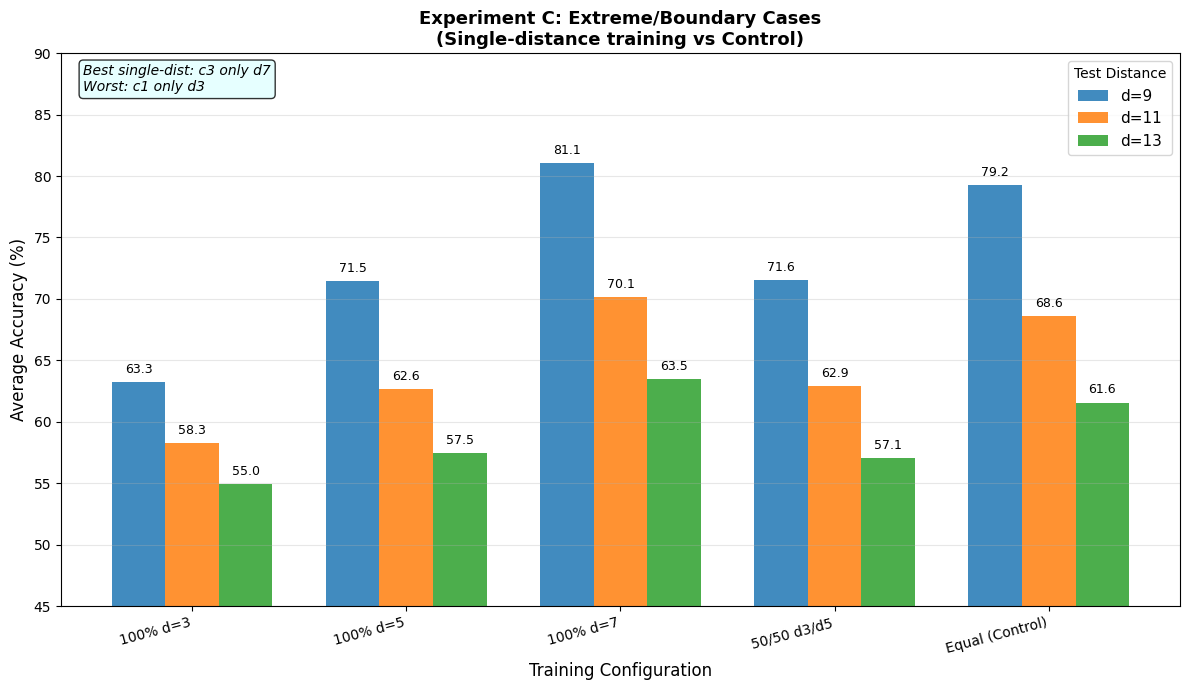


Experiment C Results (Extreme/Boundary Cases):
----------------------------------------------------------------------
Configuration        d=9 Acc      d=11 Acc     d=13 Acc    
----------------------------------------------------------------------
100% d=3             63.26        58.26        54.95       
100% d=5             71.47        62.63        57.48       
100% d=7             81.06        70.13        63.49       
50/50 d3/d5          71.56        62.88        57.06       
Equal (Control)      79.23        68.63        61.57       


In [ ]:
# =============================================================================
# EXPERIMENT C: Extreme/Boundary Cases
# =============================================================================
# Splits: c1_only_d3 (100% d3), c2_only_d5 (100% d5), c3_only_d7 (100% d7), c4_no_d7 (50/50 d3/d5)
# Also compare with equal_333333 (control)

# Define Experiment C configuration
exp_c_splits = {
    'c1_only_d3': {'d3': 1.00, 'd5': 0.00, 'd7': 0.00, 'label': '100% d=3'},
    'c2_only_d5': {'d3': 0.00, 'd5': 1.00, 'd7': 0.00, 'label': '100% d=5'},
    'c3_only_d7': {'d3': 0.00, 'd5': 0.00, 'd7': 1.00, 'label': '100% d=7'},
    'c4_no_d7':   {'d3': 0.50, 'd5': 0.50, 'd7': 0.00, 'label': '50/50 d3/d5'},
    'equal_333333': {'d3': 0.33, 'd5': 0.33, 'd7': 0.34, 'label': 'Equal (Control)'},
}

# Extract accuracies
exp_c_acc = {d: [] for d in TEST_DISTANCES}
exp_c_labels = []
exp_c_names = []

for split_name, config in exp_c_splits.items():
    if split_name in df_results['split_name'].values:
        exp_c_labels.append(config['label'])
        exp_c_names.append(split_name)
        
        for d in TEST_DISTANCES:
            subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
            if len(subset) > 0:
                exp_c_acc[d].append(subset['accuracy'].mean() * 100)
            else:
                exp_c_acc[d].append(np.nan)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(exp_c_labels))
width = 0.25

colors_dist = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, d in enumerate(TEST_DISTANCES):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, exp_c_acc[d], width, label=f'd={d}', color=colors_dist[i], alpha=0.85)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Training Configuration', fontsize=12)
ax.set_ylabel('Average Accuracy (%)', fontsize=12)
ax.set_title('Experiment C: Extreme/Boundary Cases\n(Single-distance training vs Control)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(exp_c_labels, rotation=15, ha='right')
ax.legend(loc='upper right', fontsize=11, title='Test Distance')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([45, 90])

# Add insight annotations
# Find best and worst single-distance training
single_dist_names = ['c1_only_d3', 'c2_only_d5', 'c3_only_d7']
single_dist_accs = []
for name in single_dist_names:
    if name in exp_c_names:
        idx = exp_c_names.index(name)
        single_dist_accs.append(exp_c_acc[TEST_DISTANCES[0]][idx])

if len(single_dist_accs) > 0:
    best_single = single_dist_names[np.argmax(single_dist_accs)]
    worst_single = single_dist_names[np.argmin(single_dist_accs)]
    insight_text = f"Best single-dist: {best_single.replace('_', ' ')}\nWorst: {worst_single.replace('_', ' ')}"
    ax.text(0.02, 0.98, insight_text, transform=ax.transAxes, fontsize=10, 
            ha='left', va='top', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plot_path = PLOTS_DIR / "experiment_c_extreme_cases.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

# Print numerical results
print("\nExperiment C Results (Extreme/Boundary Cases):")
print("-" * 70)
print(f"{'Configuration':<20} {'d=9 Acc':<12} {'d=11 Acc':<12} {'d=13 Acc':<12}")
print("-" * 70)
for i, label in enumerate(exp_c_labels):
    print(f"{label:<20} {exp_c_acc[9][i]:<12.2f} {exp_c_acc[11][i]:<12.2f} {exp_c_acc[13][i]:<12.2f}")

✓ Saved: ..\..\gSAGE\extrapolation\plots\revised_training\experiment_summary_combined.png


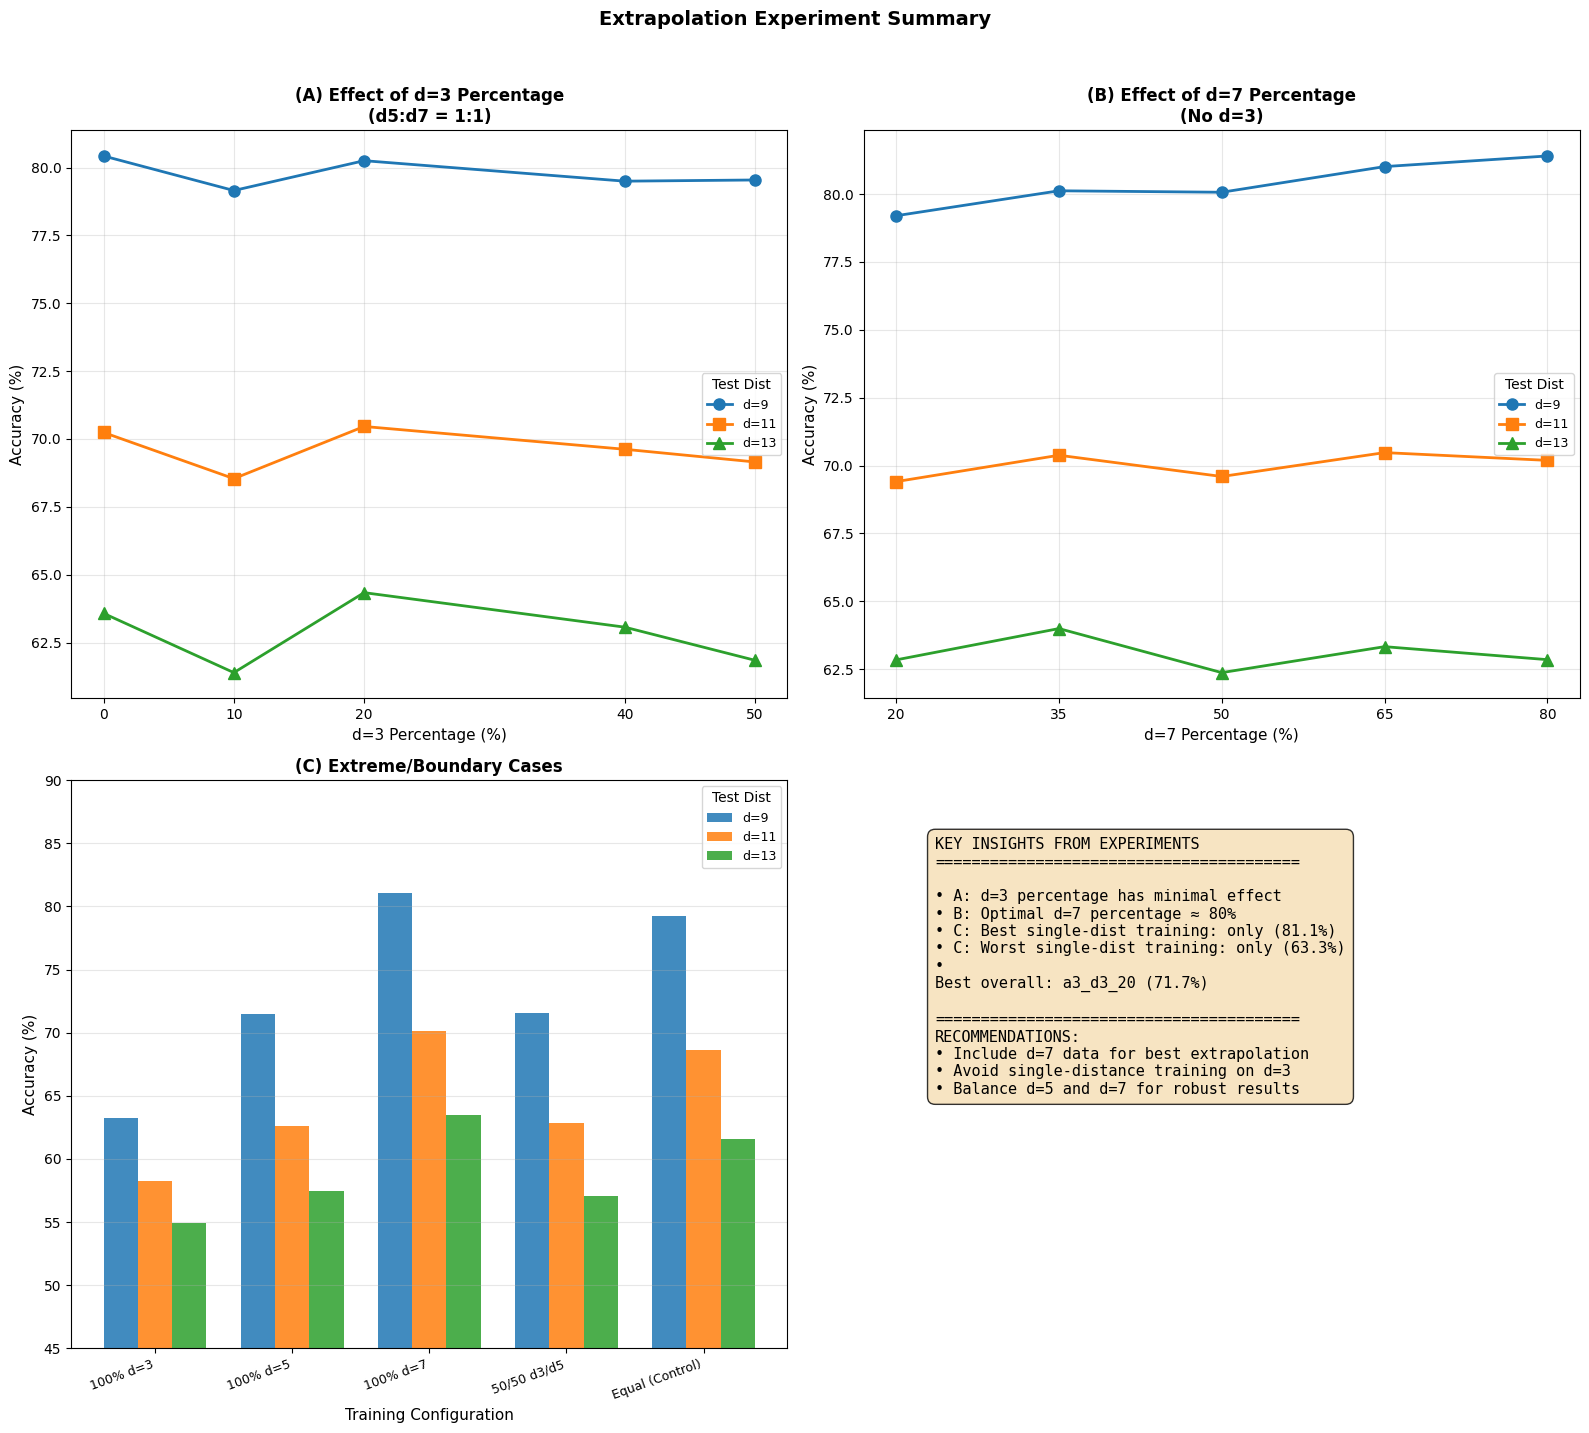

✓ Saved: ..\..\gSAGE\extrapolation\results\revised_training\experiment_patterns_summary.csv


In [ ]:
# =============================================================================
# COMBINED SUMMARY: All Experiment Insights in One Figure
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

colors_dist = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

# ----- Panel A: d=3 Ablation (Experiment A) -----
ax = axes[0, 0]
for i, d in enumerate(TEST_DISTANCES):
    if len(exp_a_d3_pct) > 0 and len(exp_a_acc[d]) > 0:
        ax.plot(exp_a_d3_pct, exp_a_acc[d], f'{markers[i]}-', 
                label=f'd={d}', color=colors_dist[i], 
                linewidth=2, markersize=8)
ax.set_xlabel('d=3 Percentage (%)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('(A) Effect of d=3 Percentage\n(d5:d7 = 1:1)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, title='Test Dist')
ax.grid(True, alpha=0.3)
if len(exp_a_d3_pct) > 0:
    ax.set_xticks(exp_a_d3_pct)

# ----- Panel B: d7 Ratio Ablation (Experiment B) -----
ax = axes[0, 1]
for i, d in enumerate(TEST_DISTANCES):
    if len(exp_b_d7_pct) > 0 and len(exp_b_acc[d]) > 0:
        ax.plot(exp_b_d7_pct, exp_b_acc[d], f'{markers[i]}-', 
                label=f'd={d}', color=colors_dist[i], 
                linewidth=2, markersize=8)
ax.set_xlabel('d=7 Percentage (%)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('(B) Effect of d=7 Percentage\n(No d=3)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, title='Test Dist')
ax.grid(True, alpha=0.3)
if len(exp_b_d7_pct) > 0:
    ax.set_xticks(exp_b_d7_pct)

# ----- Panel C: Extreme Cases (Experiment C) -----
ax = axes[1, 0]
x = np.arange(len(exp_c_labels))
width = 0.25
for i, d in enumerate(TEST_DISTANCES):
    offset = (i - 1) * width
    ax.bar(x + offset, exp_c_acc[d], width, label=f'd={d}', color=colors_dist[i], alpha=0.85)
ax.set_xlabel('Training Configuration', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('(C) Extreme/Boundary Cases', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(exp_c_labels, rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=9, title='Test Dist')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([45, 90])

# ----- Panel D: Key Insights Summary -----
ax = axes[1, 1]
ax.axis('off')

# Compute key insights
insights = []

# Experiment A insight
if len(exp_a_acc[TEST_DISTANCES[0]]) >= 2:
    trend_a = exp_a_acc[TEST_DISTANCES[0]][-1] - exp_a_acc[TEST_DISTANCES[0]][0]
    if trend_a < -1:
        insights.append("A: More d=3 data HURTS extrapolation")
    elif trend_a > 1:
        insights.append("A: More d=3 data HELPS extrapolation")
    else:
        insights.append("A: d=3 percentage has minimal effect")

# Experiment B insight
if len(exp_b_acc[TEST_DISTANCES[0]]) >= 2:
    max_idx_b = np.argmax(exp_b_acc[TEST_DISTANCES[0]])
    optimal_d7 = exp_b_d7_pct[max_idx_b]
    insights.append(f"B: Optimal d=7 percentage ≈ {optimal_d7:.0f}%")

# Experiment C insight
if len(exp_c_names) >= 3:
    single_dist_results = []
    for name in ['c1_only_d3', 'c2_only_d5', 'c3_only_d7']:
        if name in exp_c_names:
            idx = exp_c_names.index(name)
            single_dist_results.append((name, exp_c_acc[TEST_DISTANCES[0]][idx]))
    if single_dist_results:
        best = max(single_dist_results, key=lambda x: x[1])
        worst = min(single_dist_results, key=lambda x: x[1])
        insights.append(f"C: Best single-dist training: {best[0].split('_')[1]} ({best[1]:.1f}%)")
        insights.append(f"C: Worst single-dist training: {worst[0].split('_')[1]} ({worst[1]:.1f}%)")

# Overall best
overall_acc = df_results.groupby('split_name')['accuracy'].mean()
best_split = overall_acc.idxmax()
best_acc = overall_acc.max() * 100
insights.append(f"\nBest overall: {best_split} ({best_acc:.1f}%)")

# Display insights
insight_text = "KEY INSIGHTS FROM EXPERIMENTS\n" + "="*40 + "\n\n"
for insight in insights:
    insight_text += f"• {insight}\n"

insight_text += "\n" + "="*40 + "\n"
insight_text += "RECOMMENDATIONS:\n"
insight_text += "• Include d=7 data for best extrapolation\n"
insight_text += "• Avoid single-distance training on d=3\n"
insight_text += "• Balance d=5 and d=7 for robust results"

ax.text(0.1, 0.9, insight_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8))

plt.suptitle('Extrapolation Experiment Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plot_path = PLOTS_DIR / "experiment_summary_combined.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

# Save all experiment insights to a summary CSV
experiment_summary = []

# Experiment A
for i, (pct, name) in enumerate(zip(exp_a_d3_pct, exp_a_labels)):
    for d in TEST_DISTANCES:
        experiment_summary.append({
            'experiment': 'A',
            'split_name': name,
            'varied_param': 'd3_pct',
            'param_value': pct,
            'test_distance': d,
            'accuracy': exp_a_acc[d][i]
        })

# Experiment B
for i, (pct, name) in enumerate(zip(exp_b_d7_pct, exp_b_labels)):
    for d in TEST_DISTANCES:
        experiment_summary.append({
            'experiment': 'B',
            'split_name': name,
            'varied_param': 'd7_pct',
            'param_value': pct,
            'test_distance': d,
            'accuracy': exp_b_acc[d][i]
        })

# Experiment C
for i, (label, name) in enumerate(zip(exp_c_labels, exp_c_names)):
    for d in TEST_DISTANCES:
        experiment_summary.append({
            'experiment': 'C',
            'split_name': name,
            'varied_param': 'extreme_case',
            'param_value': label,
            'test_distance': d,
            'accuracy': exp_c_acc[d][i]
        })

df_experiment_summary = pd.DataFrame(experiment_summary)
summary_path = RESULTS_DIR / "experiment_patterns_summary.csv"
df_experiment_summary.to_csv(summary_path, index=False)
print(f"✓ Saved: {summary_path}")

## Analysis Summary

In [ ]:
# Compute rankings
rankings = []
for d in TEST_DISTANCES:
    d_summary = df_results[df_results['distance'] == d].groupby('split_name')['accuracy'].mean()
    d_summary = d_summary.sort_values(ascending=False)
    
    print(f"\nRanking for d={d} (best to worst):")
    for rank, (name, acc) in enumerate(d_summary.items(), 1):
        hypothesis = SPLIT_EXPERIMENTS.get(name, {}).get('hypothesis', '')
        print(f"  {rank}. {name}: {acc*100:.2f}% - {hypothesis}")
        rankings.append({'distance': d, 'rank': rank, 'split_name': name, 'accuracy': acc})


Ranking for d=9 (best to worst):
  1. b5_d7heavy: 81.40% - 
  2. c3_only_d7: 81.06% - 
  3. b4_d7more: 81.01% - 
  4. a1_d3_00: 80.43% - 
  5. a3_d3_20: 80.26% - 
  6. b2_d5more: 80.12% - 
  7. b3_balanced: 80.07% - 
  8. a5_d3_50: 79.55% - 
  9. a4_d3_40: 79.50% - 
  10. equal_333333: 79.23% - 
  11. b1_d5heavy: 79.20% - 
  12. a2_d3_10: 79.16% - 
  13. c4_no_d7: 71.56% - 
  14. c2_only_d5: 71.47% - 
  15. c1_only_d3: 63.26% - 

Ranking for d=11 (best to worst):
  1. b4_d7more: 70.48% - 
  2. a3_d3_20: 70.46% - 
  3. b2_d5more: 70.38% - 
  4. a1_d3_00: 70.24% - 
  5. b5_d7heavy: 70.19% - 
  6. c3_only_d7: 70.13% - 
  7. a4_d3_40: 69.62% - 
  8. b3_balanced: 69.60% - 
  9. b1_d5heavy: 69.41% - 
  10. a5_d3_50: 69.15% - 
  11. equal_333333: 68.63% - 
  12. a2_d3_10: 68.54% - 
  13. c4_no_d7: 62.88% - 
  14. c2_only_d5: 62.63% - 
  15. c1_only_d3: 58.26% - 

Ranking for d=13 (best to worst):
  1. a3_d3_20: 64.34% - 
  2. b2_d5more: 64.00% - 
  3. a1_d3_00: 63.57% - 
  4. c3_only_d7: 63.

In [ ]:
# Key findings
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

# Best overall performer
overall_acc = df_results.groupby('split_name')['accuracy'].mean()
best_split = overall_acc.idxmax()
best_acc = overall_acc.max()
print(f"\n1. Best overall extrapolation: {best_split} ({best_acc*100:.2f}% average accuracy)")

# Worst performer
worst_split = overall_acc.idxmin()
worst_acc = overall_acc.min()
print(f"2. Worst overall extrapolation: {worst_split} ({worst_acc*100:.2f}% average accuracy)")

# Accuracy gap
gap = (best_acc - worst_acc) * 100
print(f"3. Performance gap between best and worst: {gap:.2f}%")

# Compare extreme cases (Experiment C sanity check)
if 'c1_only_d3' in overall_acc.index and 'c3_only_d7' in overall_acc.index:
    only_d3_acc = overall_acc['c1_only_d3']
    only_d7_acc = overall_acc['c3_only_d7']
    print(f"4. Extreme cases (Exp C):")
    print(f"   Only d=3 training: {only_d3_acc*100:.2f}%")
    print(f"   Only d=7 training: {only_d7_acc*100:.2f}%")
    if only_d3_acc < only_d7_acc:
        print("   -> d=7 training extrapolates much better than d=3 (as expected)")

# Does removing d=3 help?
if 'equal_333333' in overall_acc.index and 'a1_d3_00' in overall_acc.index:
    baseline = overall_acc['equal_333333']
    no_d3 = overall_acc['a1_d3_00']
    diff = (no_d3 - baseline) * 100
    print(f"5. Effect of removing d=3: {diff:+.2f}% (control: {baseline*100:.2f}%, no_d3: {no_d3*100:.2f}%)")
    if diff > 0:
        print("   -> Removing d=3 IMPROVES extrapolation")
    elif diff < 0:
        print("   -> Removing d=3 HURTS extrapolation")
    else:
        print("   -> No significant effect")

# Effect of d7-heavy training
if 'b5_d7heavy' in overall_acc.index:
    d7_heavy = overall_acc['b5_d7heavy']
    print(f"6. d7-heavy training (b5_d7heavy): {d7_heavy*100:.2f}%")
    if 'equal_333333' in overall_acc.index:
        diff_from_baseline = (d7_heavy - overall_acc['equal_333333']) * 100
        print(f"   -> {diff_from_baseline:+.2f}% vs control")


KEY FINDINGS

1. Best overall extrapolation: a3_d3_20 (71.69% average accuracy)
2. Worst overall extrapolation: c1_only_d3 (58.82% average accuracy)
3. Performance gap between best and worst: 12.86%
4. Extreme cases (Exp C):
   Only d=3 training: 58.82%
   Only d=7 training: 71.56%
   -> d=7 training extrapolates much better than d=3 (as expected)
5. Effect of removing d=3: +1.61% (control: 69.81%, no_d3: 71.41%)
   -> Removing d=3 IMPROVES extrapolation
6. d7-heavy training (b5_d7heavy): 71.48%
   -> +1.67% vs control


## Conclusions

Based on the extrapolation results:

1. **Best Split for Extrapolation**: [Fill based on results]
2. **Effect of d=3 Data**: [Fill based on results]
3. **Effect of More d=7 Data**: [Fill based on results]
4. **Sanity Check**: [Fill based on results]

### Recommendations

[Fill based on experimental findings]